In [ ]:
#| label: setup-imports
#| echo: false
import warnings
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
torch.cuda.set_device(0)


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch CUDA version: {torch.version.cuda}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tsfeatures import tsfeatures

from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE, MSE, SMAPE, RMSE, MASE
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse, mase, mape, smape
from functools import partial
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, Naive

custom_palette = [
    "black",        # Anchor
    "#0072B2",      # Blue
    "#E69F00",      # Orange
    "#009E73",      # Green
    "#56B4E9",      # Light Blue
    "#F0E442",      # Yellow
    "#D55E00",      # Red-Orange
    "#CC79A7",      # Purple
    "#666666",      # Dark Gray
    "#009EAA",      # Teal
    "#332288"       # Dark Blue
]

PyTorch version: 2.5.1+cu121
CUDA available: True
PyTorch CUDA version: 12.1


In [ ]:
#| label: data-loading
#| echo: false

# Define forecasting horizon and model parameters
h = 28  # 28 day forecast horizon


# Structure data with required columns
#df = pd.read_csv('C:\\Users\\retailexp\\Documents\\GitHub\\tsfwpt\\data\\M5_t20_ABC.csv')
df = pd.read_csv(r'C:\Users\retailexp\Documents\Research and development\Graeme\data\m5-forecasting-accuracy\M5_CA_3.csv')

df['timestamp'] = pd.to_datetime(df['ds']) # or date 
df = df.rename(columns={
    'id': 'unique_id',  # Series identifier
    #'date': 'ds',
    'sold': 'y',        # Target variable
    'sell_price': 'price'  # Static/dynamic feature
})

df['ds'] = pd.to_datetime(df['ds'])

df = df[['unique_id', 'ds', 'y', 'price']].copy()

# drop any time series (unique_id) with less than 365 days of data
df = df.groupby('unique_id').filter(lambda x: len(x) >= 365).reset_index(drop=True)

df['y'] = df['y'] + 1  # Shift y values by 1 to avoid zero values, we can remove this later if we want, which we would in production.  

df.head()

,unique_id,ds,y,price
0,FOODS_1_001_CA_3,2011-01-29,2.0,2.0
1,FOODS_1_001_CA_3,2011-01-30,3.0,2.0
2,FOODS_1_001_CA_3,2011-01-31,2.0,2.0
3,FOODS_1_001_CA_3,2011-02-01,2.0,2.0
4,FOODS_1_001_CA_3,2011-02-02,2.0,2.0


In [ ]:
#| label: data-preprocessing
#| echo: false

# Define cut point (remove 28 days), and forecast horizon
#cutpoint = 28  
h = 90

# Group by unique_id and apply the cutoff
#df = df.groupby('unique_id').apply(lambda x: x.iloc[:-cutpoint]).reset_index(drop=True).copy()

print("DataFrame, check last 28 days removed")
print(df.tail(n=3))

# Create validation cutoff point
cutoff_date = df['ds'].max() - pd.Timedelta(days=90)

# Split maintaining temporal integrity
train_df = df[df['ds'] <= cutoff_date].reset_index(drop=True)
val_df = df[df['ds'] > cutoff_date].reset_index(drop=True)

DataFrame, check last 28 days removed
                    unique_id         ds    y  price
4833369  HOUSEHOLD_2_516_CA_3 2016-06-15  1.0   5.94
4833370  HOUSEHOLD_2_516_CA_3 2016-06-16  1.0   5.94
4833371  HOUSEHOLD_2_516_CA_3 2016-06-17  1.0   5.94
4833372  HOUSEHOLD_2_516_CA_3 2016-06-18  1.0   5.94
4833373  HOUSEHOLD_2_516_CA_3 2016-06-19  1.0   5.94


In [9]:
val_df.head(n=3)

,unique_id,ds,y,price
0,FOODS_1_001_CA_3,2016-03-22,1.0,2.24
1,FOODS_1_001_CA_3,2016-03-23,2.0,2.24
2,FOODS_1_001_CA_3,2016-03-24,2.0,2.24


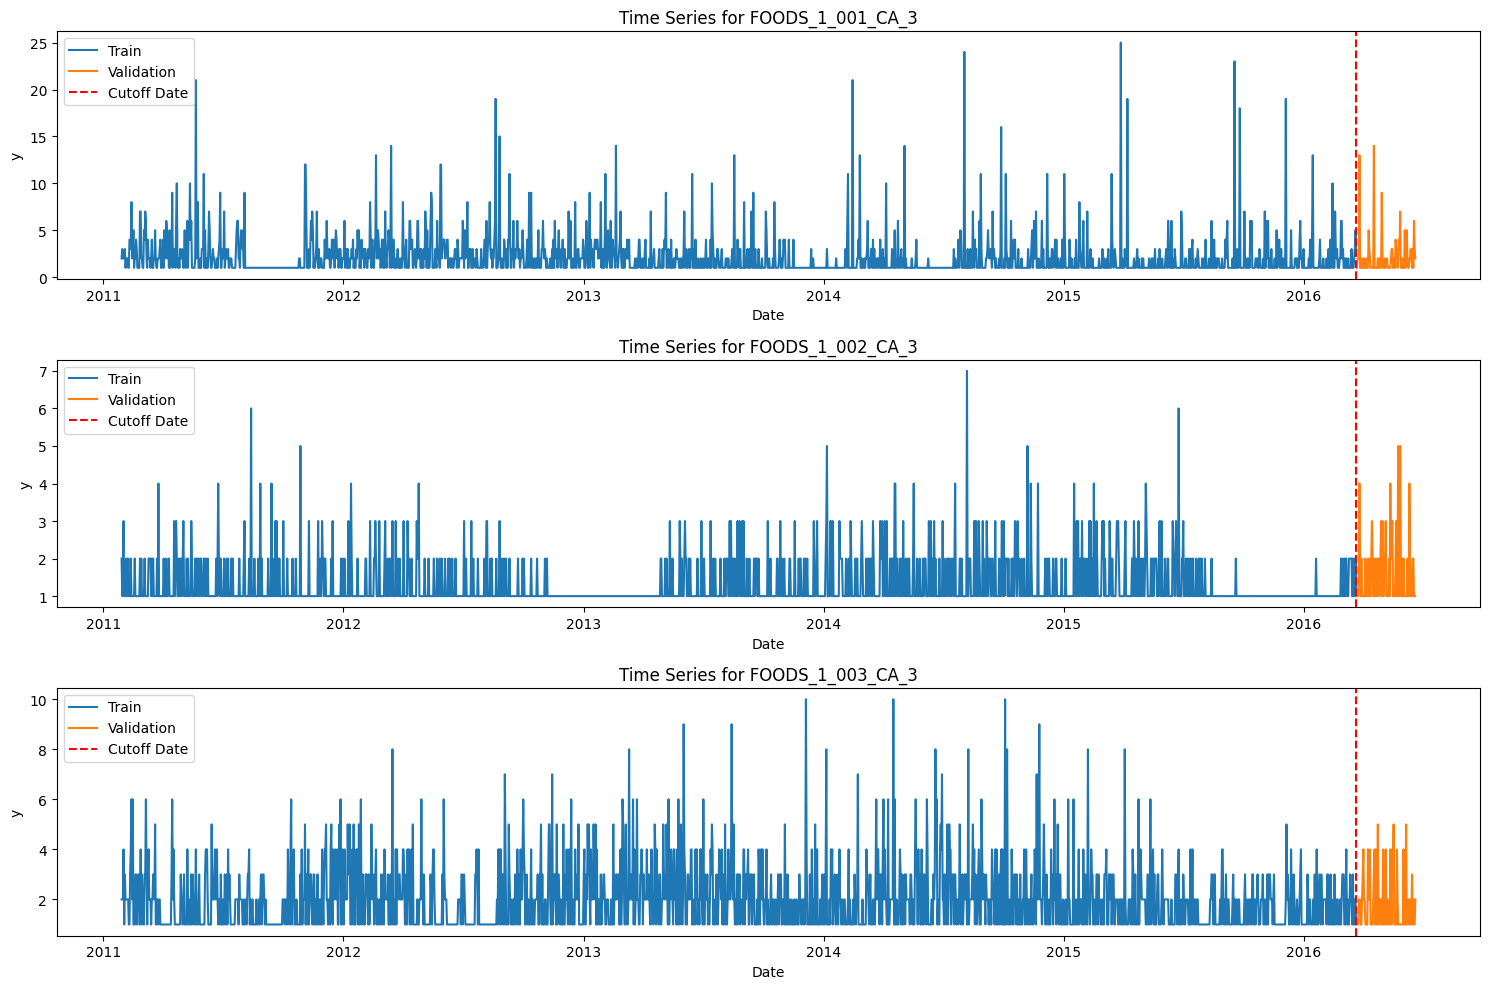

In [ ]:
#| label: fig-timeseries-plots
#| fig-cap: "Time series visualization showing train/validation split for sample series"
#| echo: false

# Select a few unique_ids to plot
unique_ids_to_plot = df['unique_id'].unique()[:3]

plt.figure(figsize=(15, 10))

for i, unique_id in enumerate(unique_ids_to_plot, 1):
    plt.subplot(len(unique_ids_to_plot), 1, i)
    plt.plot(train_df[train_df['unique_id'] == unique_id]['ds'], train_df[train_df['unique_id'] == unique_id]['y'], label='Train')
    plt.plot(val_df[val_df['unique_id'] == unique_id]['ds'], val_df[val_df['unique_id'] == unique_id]['y'], label='Validation')
    plt.axvline(cutoff_date, color='r', linestyle='--', label='Cutoff Date')
    plt.title(f'Time Series for {unique_id}')
    plt.xlabel('Date')
    plt.ylabel('y')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# feature_df = tsfeatures(train_df, dict_freqs={'D': 7, 'W': 52}) # tsfeatures tries to infer the frequency of the time series, but we can specify it manually

In [ ]:
#| label: feature-extraction
#| echo: false

from tsfeatures import (
	acf_features, heterogeneity, series_length,
	arch_stat, holt_parameters, sparsity,
	count_entropy, hurst, stability,
	crossing_points, hw_parameters, stl_features,
	entropy, intervals, unitroot_kpss,
	flat_spots, lumpiness, unitroot_pp,
	frequency, nonlinearity,
	guerrero, pacf_features
)

# we can specify the features we want to compute
default_feats = [
    acf_features, heterogeneity, series_length,
	arch_stat, holt_parameters, sparsity,
	count_entropy, hurst, stability,
	crossing_points, hw_parameters, stl_features,
	entropy, intervals, unitroot_kpss,
	flat_spots, lumpiness, unitroot_pp,
	frequency, nonlinearity,
	guerrero, pacf_features
]

feature_df = tsfeatures(
    train_df, 
    dict_freqs={'D': 7, 'W': 52}, 
    features= default_feats
)

In [13]:
train_df.head(n=3)

,unique_id,ds,y,price
0,FOODS_1_001_CA_3,2011-01-29,2.0,2.0
1,FOODS_1_001_CA_3,2011-01-30,3.0,2.0
2,FOODS_1_001_CA_3,2011-01-31,2.0,2.0


In [14]:
print(feature_df.head(n=3))

          unique_id   x_pacf5  diff1x_pacf5  diff2x_pacf5  seas_pacf  \
0  FOODS_1_001_CA_3  0.053626      0.428936      0.969541   0.088580   
1  FOODS_1_002_CA_3  0.022441      0.471350      1.001214   0.079488   
2  FOODS_1_003_CA_3  0.023560      0.442923      1.009167   0.038287   

   guerrero  nonlinearity  frequency  unitroot_pp  lumpiness  ...  garch_acf  \
0  0.088717      0.080373          7 -1934.505856   0.043011  ...        NaN   
1  0.037846     -0.087364          7 -2043.274263   0.057990  ...        NaN   
2  0.138835      0.015752          7 -1916.865742   0.054429  ...        NaN   

   arch_r2  garch_r2    x_acf1   x_acf10  diff1_acf1  diff1_acf10  diff2_acf1  \
0      NaN       NaN  0.078437  0.032825   -0.466412     0.220690   -0.649003   
1      NaN       NaN  0.061713  0.027545   -0.485404     0.238831   -0.658665   
2      NaN       NaN  0.077310  0.027562   -0.476408     0.237132   -0.647111   

   diff2_acf10  seas_acf1  
0     0.442713   0.065749  
1     0.4

In [15]:
# We can add custom features - this can significantly slow down the feature extraction process, depending on how the feature is computed.
def number_zeros(x, _):
    return {'number_zeros': (x.values == 0).sum()}

def max_value(x, _):
    return {'max_value': x.max()}

def min_value(x, _):
    return {'min_value': x.min()}

# def recent_moving_average(x, _):
#     window = 7
#     if len(x) < window:
#         avg = x.mean()
#     else:
#         avg = x.values[-window:].mean()
#     return {'recent_moving_average': avg}


# new_features = default_feats + [
#     number_zeros,
#     max_value,
#     min_value,  
#     # recent_moving_average
# ]


Another good option is to use `tsfel`, this is considerably slower then `ts features` but builds a greater set of features, this can be limited to specific features e.g. statistical features, temporal features, spectral features, etc (see the [documentation](https://tsfel.readthedocs.io/en/latest/descriptions/feature_list.html) for more details). Doing the comprehendsive feature extraction can take a long time, so we would recommended testing this a subset of your data before expanding to a dataset >1000 series (with say >1000 observations). It takes 20 minutes to run our ~3000 series with ~1000 observations each. We could distribute each series to its own worker/core, but this is not currently implemented in the `tsfel` library. Although it can run calculations for a single series in parallel.

In [ ]:
# import tsfel
# from tqdm import tqdm

# def extract_tsfel_features(train_df, target_col='y'):
#     cfg = tsfel.get_features_by_domain("statistical", )  # Only statistical features - other options include "temporal", "spectral", "fractal", and "all". But these stuggles with certain types of data
#     unique_ids = train_df['unique_id'].unique()
#     feature_list = []
    
#     for unique_id in tqdm(unique_ids, desc="Extracting features"):
#         ts_data = train_df[train_df['unique_id'] == unique_id][target_col].values
        
#         if len(ts_data) < 10 or np.isnan(ts_data).all():
#             continue
            
#         try:
#             ts_data_2d = ts_data.reshape(1, -1)
#             features = tsfel.time_series_features_extractor(cfg, 
#                                                             ts_data_2d, 
#                                                             verbose=-1,     # silent mode - change 1 is if you want to see progress or errors
#                                                             fs=1,           # fs=1 assumes the data is sampled at 1Hz, or 1 day
#                                                             n_jobs = 10     # change to suit your system's capabilities
#                                                             ) 
#             features['unique_id'] = unique_id
#             feature_list.append(features)
#         except:
#             continue
    
#     if feature_list:
#         feature_df = pd.concat(feature_list, ignore_index=True)
#         cols = ['unique_id'] + [col for col in feature_df.columns if col != 'unique_id']
#         return feature_df[cols].reset_index(drop=True)
#     else:
#         return pd.DataFrame()



# feature_df_tsfel = extract_tsfel_features(train_df, target_col='y')

Extracting features:   3%|▎         | 83/3038 [03:14<1:53:06,  2.30s/it]

Lets carry on with the `ts features` set, we need to do some clean up of the features, we can remove any series with NaN values or no variance (i.e. single value series). As these features don't help us cluster the data, although they may indicate a need to investigate your data further.


In [17]:
# You can see we have some features, like hurst, which have some NaN values. 
# When we first ran this, when looking at the extent of this problem with `print(feature_df.isna().sum())` we found alot of time series with NaN values in hurst. The options here was to 
# 1. remove these rows
# 2. impute them
# 3. remove the columns with NaN values 

# I think that best thing to do here to shift the y values by 1 of df by 1, so hurst does not produce 0s.
print(feature_df.isna().sum())

unique_id               0
x_pacf5                 0
diff1x_pacf5            0
diff2x_pacf5            0
seas_pacf               0
guerrero                1
nonlinearity            0
frequency               0
unitroot_pp             1
lumpiness               0
flat_spots              0
unitroot_kpss           0
intervals_mean          0
intervals_sd         3038
entropy                 0
nperiods                0
seasonal_period         0
trend                   0
spike                   0
linearity               0
curvature               0
e_acf1                  0
e_acf10                 0
seasonal_strength       0
peak                    0
trough                  0
hw_alpha                0
hw_beta                 0
hw_gamma                0
crossing_points         0
stability               0
hurst                 465
count_entropy           0
sparsity                0
alpha                   0
beta                    0
arch_lm                 0
series_length           0
arch_acf    

In [18]:
# Remove series with NaN or no variance
feature_df = feature_df.dropna(axis=1) # Drop columns with NaN values
# Drop columns with no variance (i.e. single value)
feature_df = feature_df.loc[:, feature_df.nunique(dropna=False) > 1]  
feature_df.shape

(3038, 37)

In [19]:
print(feature_df.isna().sum())

unique_id            0
x_pacf5              0
diff1x_pacf5         0
diff2x_pacf5         0
seas_pacf            0
nonlinearity         0
lumpiness            0
flat_spots           0
unitroot_kpss        0
intervals_mean       0
entropy              0
trend                0
spike                0
linearity            0
curvature            0
e_acf1               0
e_acf10              0
seasonal_strength    0
peak                 0
trough               0
hw_alpha             0
hw_beta              0
hw_gamma             0
crossing_points      0
stability            0
count_entropy        0
alpha                0
beta                 0
arch_lm              0
series_length        0
x_acf1               0
x_acf10              0
diff1_acf1           0
diff1_acf10          0
diff2_acf1           0
diff2_acf10          0
seas_acf1            0
dtype: int64


In [ ]:
# So now we have out data what do we do with it? Good question I'm glad you asked! 
# Well whats clear is that we have a few columns with NaN values, that we should have never built

In [ ]:
feature_df.shape

(3038, 37)

In [20]:
# At this point we have removed all the columns that have no variance or NaN values (normally we would have taken the time to decide which to create/use). We have 37 features  
feature_df.head(n =3)

,unique_id,x_pacf5,diff1x_pacf5,diff2x_pacf5,seas_pacf,nonlinearity,lumpiness,flat_spots,unitroot_kpss,intervals_mean,...,beta,arch_lm,series_length,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,FOODS_1_001_CA_3,0.053626,0.428936,0.969541,0.088580,0.080373,0.043011,82,3.744553,-90.009788,...,0.000000e+00,0.011808,1879,0.078437,0.032825,-0.466412,0.220690,-0.649003,0.442713,0.065749
1,FOODS_1_002_CA_3,0.022441,0.471350,1.001214,0.079488,-0.087364,0.057990,172,0.695790,-252.545297,...,8.217039e-09,0.003287,1879,0.061713,0.027545,-0.485404,0.238831,-0.658665,0.462176,0.068447
2,FOODS_1_003_CA_3,0.023560,0.442923,1.009167,0.038287,0.015752,0.054429,27,0.580661,-176.637167,...,4.629809e-19,0.004577,1879,0.077310,0.027562,-0.476408,0.237132,-0.647111,0.443996,0.064054


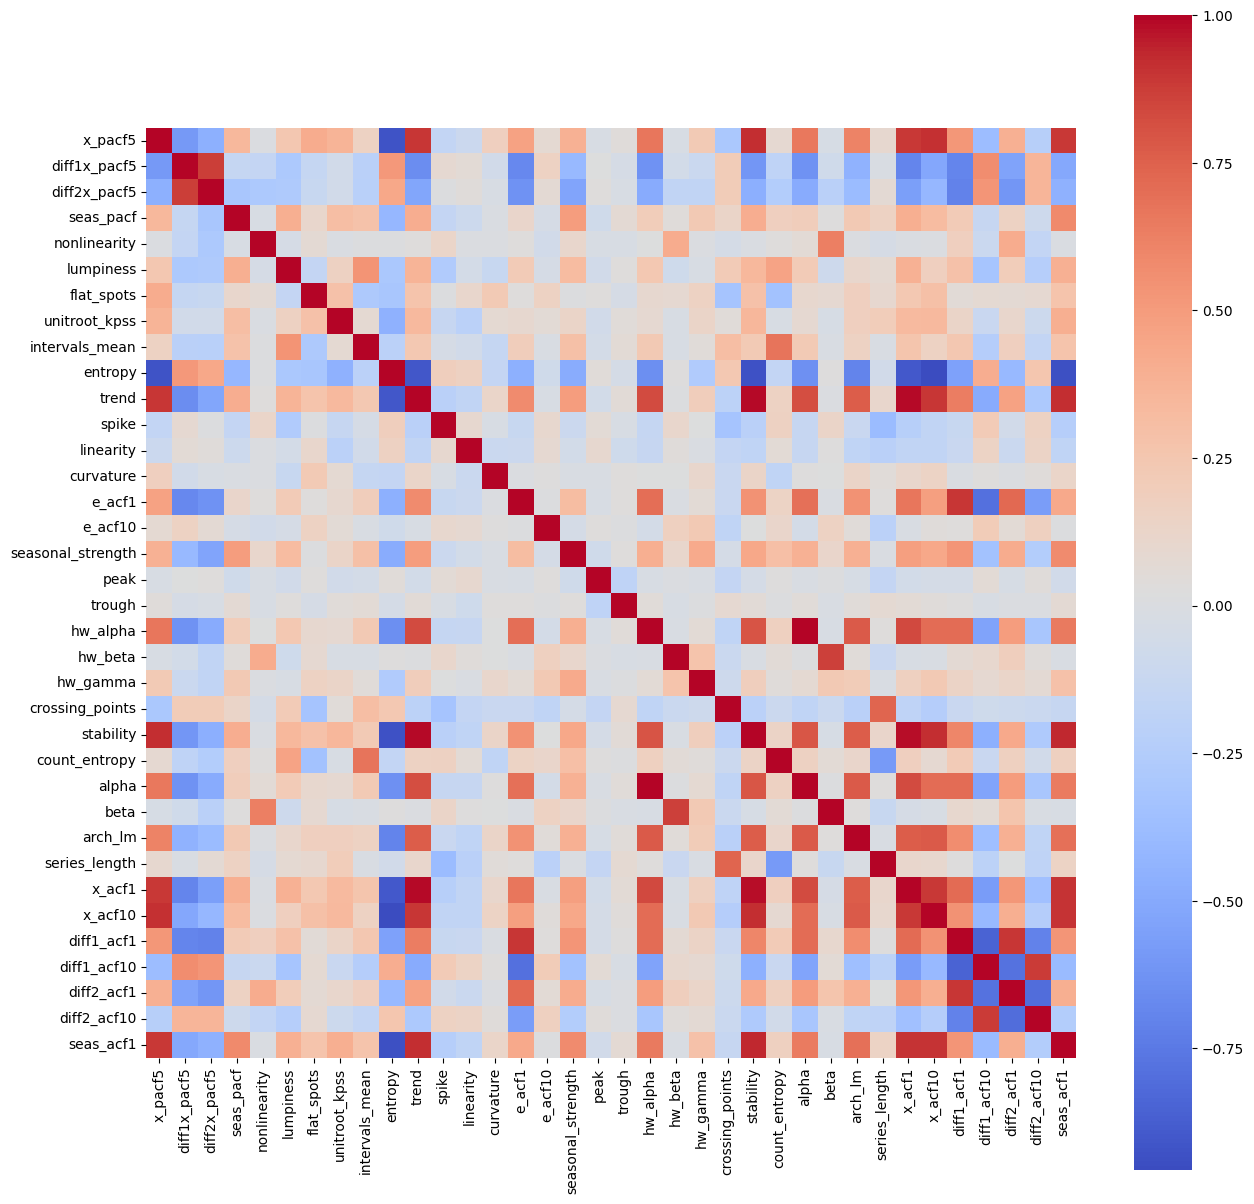

In [ ]:
#| label: fig-feature-correlation
#| fig-cap: "Correlation heatmap of extracted time series features"
#| echo: false

# Now we have our features we should take a look at them with a heatmap, this a good way to see the variance and patterns in the data.

plt.figure(figsize=(15, 15))
sns.heatmap(feature_df.drop(['unique_id'], axis=1).corr(), annot=False, fmt=".2f", cmap='coolwarm', square=True)
plt.show()


Fairly complex isn't it. Overall it shows us that some features are highly correlated, such as auto correlation. Or unitroot and flatspots. Variance across the features is what we want to see, even if we can reduce them down, your preference should be to avoid this. Or use something like ridge regression to select the best features.   

In [22]:
# Scale the features with normalization
from sklearn.preprocessing import minmax_scale
feature_df_scaled = feature_df.copy()
feature_df_scaled.iloc[:, 2:] = minmax_scale(feature_df_scaled.iloc[:, 2:])


In [ ]:
#| label: hopkins-test
#| echo: false

# Now that we have scaled our features we can get on with our clustering
# First lets see if hopkins tells us that we can cluster with our data...spolier alert, it's often useless, but we can use it to see if we have a good distribution of points

from sklearn.neighbors import NearestNeighbors

def hopkins(X, frac=0.1, random_state=None):
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    m = int(frac * n)
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # sample m real points
    real_idx = rng.choice(n, m, replace=False)
    real = X[real_idx]

    # generate m uniform points within the bounding hyper‐rectangle
    mins, maxs = X.min(axis=0), X.max(axis=0)
    uniform = rng.uniform(mins, maxs, size=(m, d))

    # compute 2-NN distances (first neighbour is itself for real points)
    u_dist = nbrs.kneighbors(uniform, return_distance=True)[0][:, 1]
    w_dist = nbrs.kneighbors(real,    return_distance=True)[0][:, 1]

    return u_dist.sum() / (u_dist.sum() + w_dist.sum())

# Lets compare our scaled and unscaled data
X = feature_df_scaled.drop(['unique_id'], axis=1).values

h2 = hopkins(X, frac=0.1, random_state=562456)
print(f"Hopkins: {h2:.4f}") 


Hopkins: 0.8584


Seems like we have some cause for clustering with a Hopkin's of >0.85 for both scaled and unscaled data, which is well above the 0.5 threshold. We were going to anyway! 

In [24]:
# Lets chack out elbow plots to see if we can find a good number of clusters
# We will use the distortion and Calinski-Harabasz metrics to find the optimal number
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from yellowbrick.cluster import KElbowVisualizer

def kmeans_elbow(
    X,
    palette,
    k_distortion=(1, 11),
    k_ch=(2, 8),
    figsize=(12, 5),
    title_fontsize=16,
    label_fontsize=9,
    color_grid="lightgray"
):
    """
    Display two K-Means elbow plots: distortion and Calinski-Harabasz.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    palette : list of colors
        Seaborn palette for the elbow plots.
    k_distortion : tuple (min_k, max_k)
        Range of K to search for distortion elbow.
    k_ch : tuple (min_k, max_k)
        Range of K to search for Calinski-Harabasz elbow.
    """
    # apply your palette globally
    sns.set_palette(palette)

    # prepare subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    model = KMeans(random_state=4)

    # 1) Distortion (inertia) elbow
    viz1 = KElbowVisualizer(
        model,
        k=k_distortion,
        ax=ax1,
        metric="distortion",
        timings=False
    )
    viz1.fit(X)
    viz1.finalize()
    ax1.set_title("Distortion Elbow", fontsize=label_fontsize, fontweight="bold")
    ax1.set_xlabel("K", fontsize=label_fontsize)
    ax1.set_ylabel("Distortion", fontsize=label_fontsize)
    ax1.grid(axis="y", linestyle=":", color=color_grid, alpha=0.7)

    # 2) Calinski-Harabasz elbow
    viz2 = KElbowVisualizer(
        model,
        k=k_ch,
        metric="calinski_harabasz",
        ax=ax2,
        timings=False
    )
    viz2.fit(X)
    viz2.finalize()
    ax2.set_title("Calinski-Harabasz Elbow", fontsize=label_fontsize, fontweight="bold")
    ax2.set_xlabel("K", fontsize=label_fontsize)
    ax2.set_ylabel("Calinski-Harabasz Score", fontsize=label_fontsize)
    ax2.grid(axis="y", linestyle=":", color=color_grid, alpha=0.7)

    # super-title and layout
    fig.suptitle("K-Means Elbow Analysis",
                 fontsize=title_fontsize, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

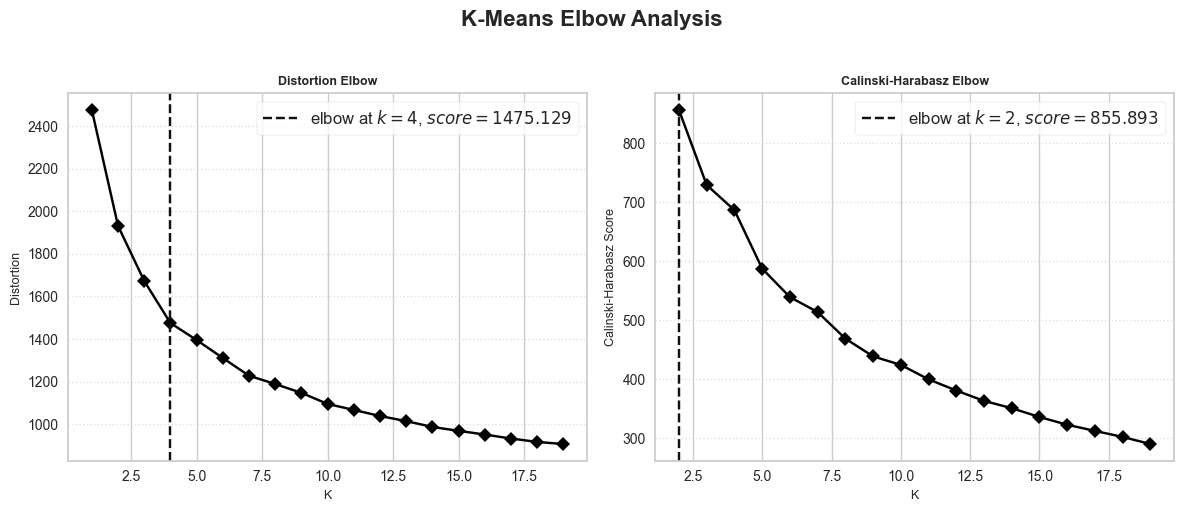

In [ ]:
#| label: fig-elbow-analysis
#| fig-cap: "K-means elbow analysis using distortion and Calinski-Harabasz metrics"
#| echo: false

kmeans_elbow(
    X=X,
    palette=custom_palette,
    k_distortion=(1, 20),
    k_ch=(2, 20),
)

Calinski-Harabasz (CH) compares the dispersion between clusters to dispersion within clusters. Conversly to dispersion a higher, rather than lower value means clusters are dense and well-separated.

There are about three main patterns to look for with CH and dispersion
- **Elbow or Peak:**  
    If the CH values show a clear peak (valley for dispersion) or an abrupt "elbow," we should choose the number of clusters at this point. As it suggests an optimal balance between compactness and separation.

- **Smooth Pattern:**  
    If the CH index increases smoothly or remains flat, there is no strong evidence for a particular number of clusters. In this case, there is no real exact number of clusters to choose, so domain knowledge and eda on the clusters should guide the decision.

- **Variable Pattern:**  
    If the CH index fluctuates, you supposed to look for local maxima or points where the increase slows down significantly. These may indicate reasonable choices for the number of clusters.

Regardless the CH index here on scaled data is 2, which is ridiculously low. CH is not a good metric for this data.  

With the unscaled data, the CH index is 4 or 6, and seems to work better. For the dispersion graphs are similar scalled with smooth declines from k = 2 onwards.   

Well thats uncertain, is it 2, 4 or 8? Tbh under distortion it could be 20, while under Calinski-Harabasz it could easily be 8. Lets go with 8 and see what happens. We'll visualise with silhouette scores and create a straightforward k-means, which will plot using pca to get a general idea.

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.manifold import TSNE

def kmeans_cluster_visuals(X, kmeans, y_kmeans, cluster_colors, font_main, font_alt, color_grid, color_line, scatter_color_edge):
    """
    Generate K-Means clustering diagnostics: silhouette plot and cluster scatter.
    """
    # -- Figure/axes: 1 row, 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # -- 1. Silhouette plot
    s_viz = SilhouetteVisualizer(kmeans, ax=ax1, colors=cluster_colors)
    s_viz.fit(X)
    s_viz.finalize()
    ax1.set_title('Silhouette Plot of Clusters', fontsize=13, fontweight='bold', fontname=font_main)
    ax1.set_xlabel('Coefficient Values', fontsize=9, fontweight='bold', fontname=font_main)
    ax1.set_ylabel('Cluster Labels', fontsize=9, fontweight='bold', fontname=font_main)
    ax1.tick_params(labelsize=8)
    ax1.grid(axis='x', alpha=0.5, color=color_grid, linestyle='dotted')
    for spine in ax1.spines.values(): spine.set_color('None')

    # -- 2. Apply t-SNE transformation
    tsne = TSNE(n_components=2, random_state=542346, perplexity=50, n_iter=1000)
    X_tsne = tsne.fit_transform(X)
    
    # -- Scatter plot of clusters in t-SNE space
    for i, color in enumerate(cluster_colors):
        ax2.scatter(X_tsne[y_kmeans == i, 0], X_tsne[y_kmeans == i, 1], 
                    s=36, c=[color], label=f"Cluster {i+1}", linewidth=0.65, edgecolor=scatter_color_edge, alpha=0.9)
    
    # Transform centroids to t-SNE space (approximate by finding mean of cluster points in t-SNE space)
    centroids_tsne = []
    for i in range(len(cluster_colors)):
        cluster_points = X_tsne[y_kmeans == i]
        if len(cluster_points) > 0:
            centroid_tsne = cluster_points.mean(axis=0)
            centroids_tsne.append(centroid_tsne)
    
    if centroids_tsne:
        centroids_tsne = np.array(centroids_tsne)
        ax2.scatter(centroids_tsne[:, 0], centroids_tsne[:, 1],
                    s=70, c='#42A2FC', marker='X', label='Centroids', linewidth=0.8, edgecolor='black', alpha=1)
    
    ax2.set_title('Cluster Distribution (t-SNE projection)', fontsize=13, fontweight='bold', fontname=font_main)
    ax2.grid(alpha=0.5, color=color_grid, linestyle='dotted')
    ax2.set_xlabel('t-SNE 1', fontsize=9, fontweight='bold', fontname=font_main)
    ax2.set_ylabel('t-SNE 2', fontsize=9, fontweight='bold', fontname=font_main)
    ax2.legend(loc='upper right', fontsize=8, frameon=False)
    ax2.tick_params(axis="both", labelsize=8)
    for spine in ax2.spines.values(): spine.set_color(color_line)

    # -- Main title and credits
    plt.suptitle('Clustering using K-Means', fontsize=15, fontweight='bold', fontname=font_main)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [ ]:
#| label: clustering-execution
#| echo: false

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
k = 8
kmeans = KMeans(
  n_clusters=k, 
  init='k-means++', 
  n_init='auto',
  max_iter=300,
  algorithm = 'elkan', # standard is lloyld, but eelkan is better with well defined clusters
  random_state=5363)
y_kmeans = kmeans.fit_predict(X)


In [ ]:

# sklearn allows us to take a look at centroids of the clusters 
def get_centroids_dataframe(kmeans, feature_names):
    # Extract centroids
    centroids = kmeans.cluster_centers_
    
    centroids_df = pd.DataFrame(
        centroids,
        columns=feature_names,
        index=[f'Cluster_{i}' for i in range(len(centroids))]
    )
    return centroids_df

In [47]:
# Lets see what the centre of these clusters look like, this can be to understand the underlying representations
X_unscaled = feature_df.drop(['unique_id'], axis=1).values
feature_names = feature_df.drop(['unique_id'], axis=1).columns
centroids_df = get_centroids_dataframe(kmeans, feature_names)
centroids_df.head(n=3)

,x_pacf5,diff1x_pacf5,diff2x_pacf5,seas_pacf,nonlinearity,lumpiness,flat_spots,unitroot_kpss,intervals_mean,entropy,...,beta,arch_lm,series_length,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
Cluster_0,0.083587,0.715644,0.823732,0.420734,0.004402,0.203497,0.051675,0.123315,0.457033,0.816242,...,0.001431,0.028815,0.900545,0.243766,0.027755,0.273273,0.329791,0.164212,0.314836,0.222647
Cluster_1,0.034525,0.744882,0.842851,0.329769,0.004265,0.125000,0.124107,0.094513,0.137597,0.853706,...,0.001927,0.021731,0.891592,0.173733,0.010317,0.250937,0.348060,0.154397,0.323797,0.137877
Cluster_2,0.054537,0.718009,0.817712,0.367601,0.005956,0.178832,0.042207,0.070525,0.411616,0.826409,...,0.007932,0.034424,0.329211,0.203764,0.016325,0.267263,0.351674,0.160771,0.329478,0.173232


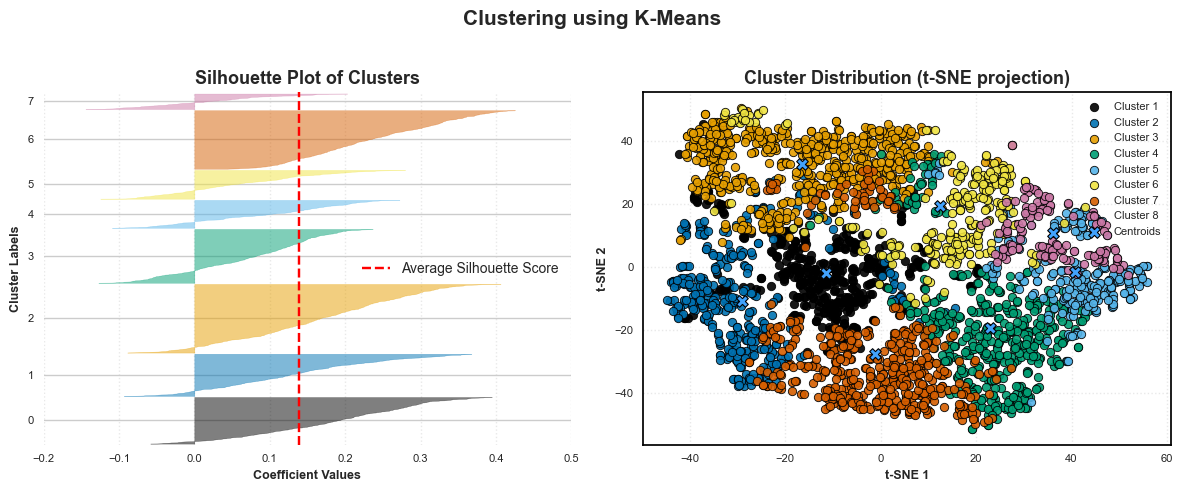

In [ ]:
#| label: fig-cluster-visualization
#| fig-cap: "Cluster visualization with silhouette scores and t-SNE projection"
#| echo: false

# scaled data
kmeans_cluster_visuals(
    X=X,
    kmeans=kmeans,
    y_kmeans=y_kmeans,
    cluster_colors = custom_palette[:k], # limit to 8 colors for clusters - needs co
    font_main='Arial',
    font_alt='Courier New',
    color_grid='lightgray',
    color_line='black',
    scatter_color_edge='black'
)

what should be immediately obvious is that the silhouette scores are all over the place for our scaled data, with some clusters having some negative scoring. A sign that our clusters are not well defined, I think this is partly due to the amount of data we have. Possibly a sign that we should have more data, or that we should use a different clustering algorithm.

In addition the t-sne also shows that the clusters are not well defined, with some clusters overlapping significantly. A sign that our apporach is not working well, and that we should consider using: 
* different algorithm - e.g. hierarchical clustering, dbscan, gaussian mixture models, self-organising maps, etc
* different number of clusters - e.g. 2, 4, 8, 16, 32, etc
* more data i.e. more feature
* wrangle the data differently - for example there is missing at random (and not at random) data that could be imputed, that likely affects our performance  
* a different dimensionality reduction technique

In [50]:
# add these labels back into df
tsne = TSNE(
        n_components=2, 
        perplexity=60, 
        n_iter=1200, 
        random_state=86743, 
        method = 'barnes_hut',
        init="pca",
        n_jobs = -1
    )

X_tsne = tsne.fit_transform(X)

In [51]:
tsne_df = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])


In [54]:
# add cluster labels to t-sne DataFrame
tsne_df['cluster'] = y_kmeans

In [55]:
tsne_df. head(n=3)

,tsne1,tsne2,cluster
0,0.389570,-27.850815,6
1,-29.302364,-13.525730,0
2,0.510849,-29.970949,6


<Axes: xlabel='tsne1', ylabel='tsne2'>

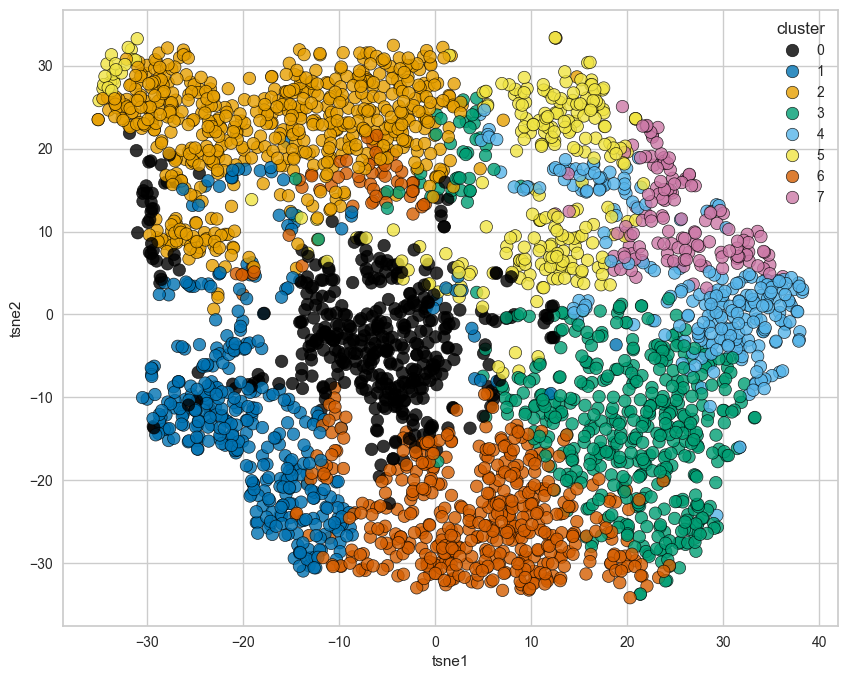

In [ ]:
#| label: fig-tsne-clusters
#| fig-cap: "t-SNE visualization of clusters in 2D space"
#| echo: false


# plot t-sne with clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df, 
    x='tsne1', 
    y='tsne2', 
    hue='cluster', 
    palette=custom_palette, 
    s=80, 
    edgecolor='black', 
    linewidth=0.5, 
    alpha=0.8
)

T-SNE is a dimensionality reduction technique, here we use it to take 37 features to 2. But by doing this the TSNE may not properly capture relative relationships between points in the 2D feature space. Overall despite the some polution in the clusters, the clusters look reasonably well defined.

We could get an idea for how well this is working by building a GFM with default parameters, that utilises the cluster labels, and compares the overall performance with a model that uses no clusters. This would give us a direct measure of how well labels help or hinder the model.

In [57]:
# join cluster labels and tsne_dimensions in tsne_df to feature_df then to time series data 
# Join feature_df and tsne_df by index/order (since both are aligned)
feature_df = pd.concat([feature_df.reset_index(drop=True), tsne_df.reset_index(drop=True)], axis=1)
feature_df.head()

,unique_id,x_pacf5,diff1x_pacf5,diff2x_pacf5,seas_pacf,nonlinearity,lumpiness,flat_spots,unitroot_kpss,intervals_mean,...,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1,tsne1,tsne2,cluster
0,FOODS_1_001_CA_3,0.053626,0.428936,0.969541,0.088580,0.080373,0.043011,82,3.744553,-90.009788,...,0.078437,0.032825,-0.466412,0.220690,-0.649003,0.442713,0.065749,0.389570,-27.850815,6
1,FOODS_1_002_CA_3,0.022441,0.471350,1.001214,0.079488,-0.087364,0.057990,172,0.695790,-252.545297,...,0.061713,0.027545,-0.485404,0.238831,-0.658665,0.462176,0.068447,-29.302364,-13.525730,0
2,FOODS_1_003_CA_3,0.023560,0.442923,1.009167,0.038287,0.015752,0.054429,27,0.580661,-176.637167,...,0.077310,0.027562,-0.476408,0.237132,-0.647111,0.443996,0.064054,0.510849,-29.970949,6
3,FOODS_1_004_CA_3,0.596114,0.271829,0.874338,0.029830,0.637502,0.085982,66,1.918097,99.993624,...,0.648860,1.988723,-0.363410,0.142784,-0.606779,0.382638,0.368683,19.889555,14.616527,4
4,FOODS_1_005_CA_3,0.253240,0.401911,0.965755,0.096300,0.319700,0.067918,94,0.570863,53.973015,...,0.233212,0.403630,-0.479127,0.232495,-0.652557,0.447152,0.206812,-0.034593,-6.116856,0


In [ ]:
# create static df for model building
# Create static DataFrame with cluster information for each unique_id
static_df = feature_df[['unique_id', 'cluster']].copy()

# One-hot encode the cluster variable
cluster_dummies = pd.get_dummies(static_df['cluster'], prefix='cluster')
static_df = pd.concat([static_df[['unique_id']], cluster_dummies], axis=1)

static_df.columns

Index(['unique_id', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3',
       'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7'],
      dtype='object')

In [ ]:
# we don't have to dummy - but it often works better with dummies
# static_df = feature_df[['unique_id', 'cluster']].copy()

In [77]:
static_df

,unique_id,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7
0,FOODS_1_001_CA_3,False,False,False,False,False,False,True,False
1,FOODS_1_002_CA_3,True,False,False,False,False,False,False,False
2,FOODS_1_003_CA_3,False,False,False,False,False,False,True,False
3,FOODS_1_004_CA_3,False,False,False,False,True,False,False,False
4,FOODS_1_005_CA_3,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
3033,HOUSEHOLD_2_512_CA_3,False,True,False,False,False,False,False,False
3034,HOUSEHOLD_2_513_CA_3,False,False,False,False,False,True,False,False
3035,HOUSEHOLD_2_514_CA_3,False,True,False,False,False,False,False,False
3036,HOUSEHOLD_2_515_CA_3,False,False,True,False,False,False,False,False


In [78]:
print(train_df.tail())
train_df.shape, val_df.shape

                    unique_id         ds    y  price
4559949  HOUSEHOLD_2_516_CA_3 2016-03-17  1.0   5.94
4559950  HOUSEHOLD_2_516_CA_3 2016-03-18  1.0   5.94
4559951  HOUSEHOLD_2_516_CA_3 2016-03-19  1.0   5.94
4559952  HOUSEHOLD_2_516_CA_3 2016-03-20  1.0   5.94
4559953  HOUSEHOLD_2_516_CA_3 2016-03-21  1.0   5.94


((4559954, 4), (273420, 4))

In [ ]:
#| label: model-setup
#| echo: false

max_steps = 3500  # Maximum training iterations
early_stop_patience= 50
h = 90 # 28 higher up for some reason


# Lets built a simple model and see how it performs
models = [
    NHITS(
        input_size=90,  # 3 months of history
        h=h,
        max_steps=max_steps,
        scaler_type='standard',    # Standardize across all series
        loss=MAE(),                # Using Mean Absolute Error
        hist_exog_list= None,      # Historic exogenous variable list
        futr_exog_list=['price'],  # Future exogenous list 
        stat_exog_list=['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7'],    
        early_stop_patience_steps=early_stop_patience,
        learning_rate= 0.001,  # Learning rate for the optimizer
        alias='NHITS_with_clusters'  # Custom name for the model
    ), 
    NHITS(
        input_size=90,
        h=h,
        max_steps=max_steps,
        scaler_type='standard',
        loss=MAE(),
        hist_exog_list=None,
        futr_exog_list=['price'],  # Keep price exogenous
        stat_exog_list=None,       # No static features
        early_stop_patience_steps=early_stop_patience,
        learning_rate=0.001,
        alias='NHITS_no_clusters'  # Custom name
    )
]

# Initialise global forecasting framework
nf = NeuralForecast(
    models=models,
    freq='D',  # Daily frequency
    #normalizer=None  # Let individual models handle scaling
)

#| label: model-training
#| echo: false

nf.fit(
    df=train_df,
    static_df=static_df,  # Static DataFrame with cluster information
    val_size=90,  # Validation window size
    verbose=True
)

Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.9 M  | train
-------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.493    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=3500` reached.


In [101]:
#lets check the losses
train_losses = nf.models[0].train_trajectories
valid_losses = nf.models[0].valid_trajectories

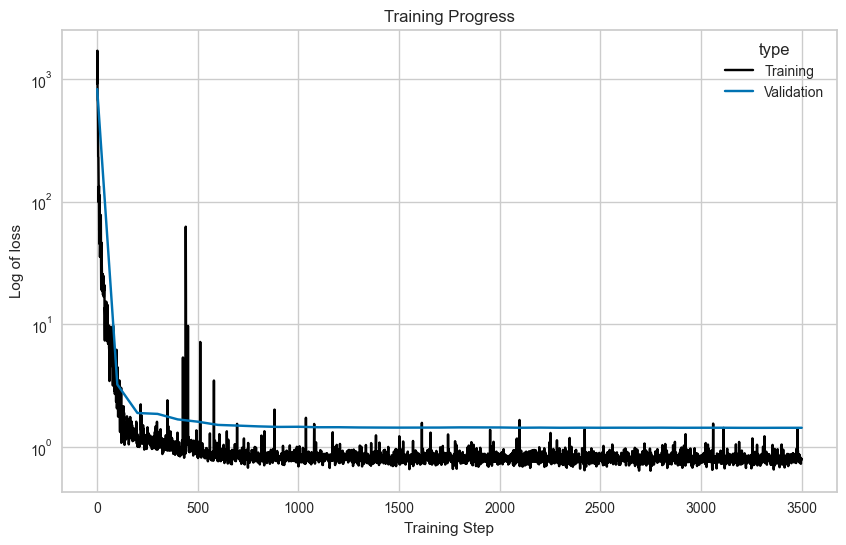

In [ ]:
#| label: fig-training-loss
#| fig-cap: "Training and validation loss curves for NHITS model"
#| echo: false

# plot loss
train_loss_df = pd.DataFrame(train_losses, columns=['step', 'loss'])
train_loss_df['type'] = 'Training'
valid_loss_df = pd.DataFrame(valid_losses, columns=['step', 'loss'])
valid_loss_df['type'] = 'Validation'

loss_df = pd.concat([train_loss_df, valid_loss_df])

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=loss_df, x='step', y='loss', hue='type')
plt.title('Training Progress')
plt.yscale('log')
plt.ylabel('Log of loss')
plt.xlabel('Training Step')
plt.show()

## What You're Seeing
Some rapid initial learning (steps 0-200), where our model learns basic patterns quickly - loss drops slowly after this to the point of imperceptability. This slow fine-tuning phase (steps 200+) is where neural networks make gradual improvements, optimising details. This is what we want because
- it appears that there is no no overfitting, as training and validation losses track closely together
- There is steady convergence, with both lines being relatively stable after the initial drop
- its likely the model is still learning, with early stopping not occuring due to lack of improvements but rather max steps, suggesting more training steps could help (it does, a little)

Importantly, it is the "slow loss" section where our model gets its final performance gains. Initally we ran this with 300 steps, but despite alot of performance gain it was still poor until we increased max steps to 3500 steps, which saw. 

Relative RMSE: 22.95 → ~0.85
Relative MAE: 2.88 → 0.80

increasing the max steps to 6000 yeilds further improvements, but the gains are not as significant as the initial increase from 300 to 3500 steps.

In [ ]:
#| label: predictions-generation
#| echo: false
# Generate predictions with validation data and static data where required
predictions = nf.predict(futr_df=val_df, static_df=static_df)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [104]:
print(predictions.head())

                         ds  NHITS_with_clusters  NHITS_no_clusters
unique_id                                                          
FOODS_1_001_CA_3 2016-03-22             1.487739           1.523633
FOODS_1_001_CA_3 2016-03-23             1.444373           1.523793
FOODS_1_001_CA_3 2016-03-24             1.366226           1.518980
FOODS_1_001_CA_3 2016-03-25             1.352583           1.492150
FOODS_1_001_CA_3 2016-03-26             1.393387           1.451231


In [ ]:
#| label: tbl-initial-metrics
#| tbl-cap: "Performance metrics comparison for initial models"
#| echo: false

# Naive model comparison - always do this! 
base_models = [
    SeasonalNaive(season_length=7),  # Weekly seasonality
    Naive()
]

sf = StatsForecast(
    df=train_df,
    models=base_models,
    freq='D',
    n_jobs=-1
)

# Generate naive predictions
naive_predictions = sf.forecast(h=h)

eval_df = predictions.merge(
    naive_predictions, 
    on=['unique_id', 'ds'], 
    how='left'
    ).merge(
        val_df[['unique_id', 'ds', 'y']], 
        on=['unique_id', 'ds'], 
        how='left'
    )

fcst_mase = partial(mase, seasonality=7)
# Get metrics for individual series
series_metrics = evaluate(
    eval_df, 
    models=['NHITS_with_clusters','NHITS_no_clusters'], # Specify your model names (in cols of eval_df)
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,      
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

# Get aggregated metrics across all series by model
agg_metrics = evaluate(
    eval_df, 
    models=['NHITS_with_clusters','NHITS_no_clusters'], # Specify your model names (in cols of eval_df)
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,
    id_col='unique_id', 
    time_col='ds',
    target_col='y',
    agg_fn='mean'
)

print("\nOverall Metrics:")
print(agg_metrics)

print("\nPer-Series Metrics (first 5):")
print(series_metrics.head())

# Overall performance by ranking
agg_metrics_subset = agg_metrics.loc[agg_metrics['metric'].isin(['mae', 'mse', 'rmse', 'mase'])] # remove APE metrics due to how they favour under or over forecasting.

# Calculate ranks for each metric (lower is better)
ranks = agg_metrics_subset.set_index('metric').rank(axis=1)
avg_rank = ranks.mean()

rank_summary = pd.DataFrame({
    'Model': avg_rank.index,
    'Average Rank': avg_rank.values
}).sort_values('Average Rank')

print("\nOverall Model Rankings (Aggregate Metrics):")
print(rank_summary)

def count_best_performances_fixed(series_metrics):
    """Count wins per metric and provide clearer summary"""
    wins = {}
    metrics = ['mae', 'mse', 'rmse', 'mase']
    
    for metric in metrics:
        metric_data = series_metrics[series_metrics['metric'] == metric]
        model_columns = [col for col in metric_data.columns if col not in ['metric', 'unique_id']]

        best_models = metric_data.set_index('unique_id')[model_columns].idxmin(axis=1)
        win_counts = best_models.value_counts()
        wins[metric] = win_counts
    
    wins_df = pd.DataFrame(wins).fillna(0)
    wins_df['total_wins'] = wins_df.sum(axis=1)
    return wins_df

def create_summary(agg_metrics, series_metrics, rank_metric='rmse'):
    agg_metrics_subset = agg_metrics.loc[agg_metrics['metric'] == rank_metric]
    ranks = agg_metrics_subset.set_index('metric').rank(axis=1)
    
    rank_summary = pd.DataFrame({
        'Model': ranks.columns,
        'Rank': ranks.iloc[0].values  # Get the single row of ranks
    }).sort_values('Rank')
    
    win_counts = count_best_performances_fixed(series_metrics)
    win_counts = win_counts.reset_index().rename(columns={'index': 'Model'})
    
    total_series = series_metrics['unique_id'].nunique()
    total_metrics = 4  # mae, mse, rmse, mase
    max_possible_wins = total_series * total_metrics
    
    print(f"Total time series: {total_series}")
    print(f"Metrics evaluated: {total_metrics}")
    print(f"Ranking based on aggregate {rank_metric.upper()}")
    print(f"Maximum possible total wins: {max_possible_wins}")
    
    # 4. Create detailed summary
    final_summary = pd.merge(rank_summary, win_counts, on='Model', how='outer').fillna(0)
    
    # Add win percentages
    final_summary['Win_Percentage'] = (final_summary['total_wins'] / max_possible_wins * 100).round(2)
    
    # Add individual metric win percentages
    for metric in ['mae', 'mse', 'rmse', 'mase']:
        col_name = f'{metric}_win_pct'
        final_summary[col_name] = (final_summary[metric] / total_series * 100).round(2)
    
    final_summary = final_summary.sort_values('Rank')
    
    return final_summary, win_counts



Overall Metrics:
  metric  NHITS_with_clusters  NHITS_no_clusters
0    mae             1.422563           1.449423
1    mse            11.188759          11.756340
2   rmse             2.015219           2.048115
3   mase             1.061908           1.069357
4   mape             0.492804           0.486487
5  smape             0.203730           0.207393

Per-Series Metrics (first 5):
          unique_id metric  NHITS_with_clusters  NHITS_no_clusters
0  FOODS_1_001_CA_3    mae             1.180247           1.188823
1  FOODS_1_002_CA_3    mae             0.657465           0.668716
2  FOODS_1_003_CA_3    mae             0.870254           0.867209
3  FOODS_1_004_CA_3    mae             5.088471           5.079937
4  FOODS_1_005_CA_3    mae             2.116465           2.161619

Overall Model Rankings (Aggregate Metrics):
                 Model  Average Rank
0  NHITS_with_clusters           1.0
1    NHITS_no_clusters           2.0


In [91]:
eval_df

,unique_id,ds,NHITS_with_clusters,NHITS_no_clusters,SeasonalNaive,Naive,y
0,FOODS_1_001_CA_3,2016-03-22,1.560487,1.910982,1.0,3.0,1.0
1,FOODS_1_001_CA_3,2016-03-23,1.532653,1.756989,1.0,3.0,2.0
2,FOODS_1_001_CA_3,2016-03-24,1.558822,1.754918,1.0,3.0,2.0
3,FOODS_1_001_CA_3,2016-03-25,1.579619,1.802832,2.0,3.0,2.0
4,FOODS_1_001_CA_3,2016-03-26,1.574285,1.717142,3.0,3.0,13.0
...,...,...,...,...,...,...,...
273415,HOUSEHOLD_2_516_CA_3,2016-06-15,0.999576,1.000737,2.0,1.0,1.0
273416,HOUSEHOLD_2_516_CA_3,2016-06-16,0.999567,1.000377,1.0,1.0,1.0
273417,HOUSEHOLD_2_516_CA_3,2016-06-17,0.999541,1.000766,1.0,1.0,1.0
273418,HOUSEHOLD_2_516_CA_3,2016-06-18,0.999689,1.001938,1.0,1.0,1.0


In [106]:
comprehensive_summary, detailed_wins = create_summary(agg_metrics, series_metrics)
print("\nComprehensive Model Performance Summary:")
print(comprehensive_summary)

# Verification
total_series = series_metrics['unique_id'].nunique()


Total time series: 3038
Metrics evaluated: 4
Ranking based on aggregate RMSE
Maximum possible total wins: 12152

Comprehensive Model Performance Summary:
                 Model  Rank   mae   mse  rmse  mase  total_wins  \
1  NHITS_with_clusters   1.0  2000  1512  1512  2000        7024   
0    NHITS_no_clusters   2.0  1038  1526  1526  1038        5128   

   Win_Percentage  mae_win_pct  mse_win_pct  rmse_win_pct  mase_win_pct  
1            57.8        65.83        49.77         49.77         65.83  
0            42.2        34.17        50.23         50.23         34.17  


In [ ]:
############### Relative metrics #####################

def rel_rmse(y_true, y_pred, y_naive):
    """
    Calculate Relative RMSE using seasonal naive as baseline
    Values < 1 indicate better performance than seasonal naive
    Values > 1 indicate worse performance than seasonal naive
    RelRMSE = √(MSE(pred) / MSE(naive))
    """
    mse_pred = np.mean((y_true - y_pred) ** 2)
    mse_naive = np.mean((y_true - y_naive) ** 2)
    return np.sqrt(mse_pred / mse_naive)

def rel_mae(y_true, y_pred, y_naive):
    """
    Calculate Relative MAE using seasonal naive as baseline
    Values < 1 indicate better performance than seasonal naive
    Values > 1 indicate worse performance than seasonal naive
    RelMAE = MAE(pred) / MAE(naive)
    """
    mae_pred = np.mean(np.abs(y_true - y_pred))
    mae_naive = np.mean(np.abs(y_true - y_naive))
    return mae_pred / mae_naive

rel_rmse_cl_val = rel_rmse(
                eval_df['y'].values,
                eval_df['NHITS_with_clusters'].values,
                eval_df['SeasonalNaive'].values
            )

rel_mae_cl_val = rel_mae(
                eval_df['y'].values,
                eval_df['NHITS_with_clusters'].values,
                eval_df['SeasonalNaive'].values
            )

rel_rmse_no_cl_val = rel_rmse(
                eval_df['y'].values,
                eval_df['NHITS_no_clusters'].values,
                eval_df['SeasonalNaive'].values
            )

rel_mae_no_cl_val = rel_mae(
                eval_df['y'].values,
                eval_df['NHITS_no_clusters'].values,
                eval_df['SeasonalNaive'].values
            )



In [ ]:
#| label: relative-metrics-initial
#| echo: false

print(f"Relative RMSE with Clusters: {rel_rmse_cl_val:.4f}")
print(f"Relative MAE with Clusters: {rel_mae_cl_val:.4f}")
print(f"Relative RMSE no Clusters: {rel_rmse_no_cl_val:.4f}")
print(f"Relative MAE no Clusters: {rel_mae_no_cl_val:.4f}")

Relative RMSE with Clusters: 0.8651
Relative MAE with Clusters: 0.8013
Relative RMSE no Clusters: 0.8868
Relative MAE no Clusters: 0.8165


After all this we only have some slight reductions in MAE and RMSE for both standard and relative metrics. But overall there is only a small difference in how well the clustering beats non clustered model. Although it is encouraging that both beat the naive model strongly. However, it could be a case that the clusters could be improved, or that the model is not complex enough to take advantage of the clusters. Lets try both of these options, first we'll attempt apply some HP tuning to automodel's then the clustered and non-clustered data, then we'll try a more complex model with the clustered data.

In [ ]:
#| label: hyperparameter-config
#| echo: false

# Hyperparameter optimization for both clustered and non-clustered NHITS models

def config_nhits_clustered(trial):
    """Hyperparameter configuration for NHITS with cluster features"""
    return {
        "random_seed":52735,
        "input_size": 90,
        "n_blocks": trial.suggest_categorical(
            "n_blocks", [[1, 1, 1], [2, 2, 2], [1, 2, 1]]
        ),
        "mlp_units": trial.suggest_categorical(
            "mlp_units", [
                [[256, 256], [256, 256], [256, 256]],
                [[512, 512], [512, 512], [512, 512]],
                [[1024, 1024], [1024, 1024], [1024, 1024]],
            ]
        ),
        "n_pool_kernel_size": trial.suggest_categorical(
            "n_pool_kernel_size", [
                [2, 2, 2], [16, 8, 1], [1, 1, 1], [4, 2, 1], [8, 4, 2]
            ]
        ),
        "n_freq_downsample": trial.suggest_categorical(
            "n_freq_downsample", [
                [168, 24, 1], [24, 12, 1], [1, 1, 1], [48, 24, 1], [12, 6, 1]
            ]
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", low=1e-4, high=1e-2, log=True
        ),
        "max_steps": trial.suggest_categorical(
            "max_steps", [3000, 4000, 6000, 8000, 10000]
        ),
        "early_stop_patience_steps": 75,
        "scaler_type": 'standard',
        "futr_exog_list": ['price'],
        "stat_exog_list": ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 
                          'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7']
    }

def config_nhits_no_clusters(trial):
    """Hyperparameter configuration for NHITS without cluster features"""
    return {
        "random_seed":52735,
        "input_size": 90,
        "n_blocks": trial.suggest_categorical(
            "n_blocks", [[1, 1, 1], [2, 2, 2], [1, 2, 1]]
        ),
        "mlp_units": trial.suggest_categorical(
            "mlp_units", [
                [[256, 256], [256, 256], [256, 256]],
                [[512, 512], [512, 512], [512, 512]],
                [[1024, 1024], [1024, 1024], [1024, 1024]],
            ]
        ),
        "n_pool_kernel_size": trial.suggest_categorical(
            "n_pool_kernel_size", [
                [2, 2, 2], [16, 8, 1], [1, 1, 1], [4, 2, 1], [8, 4, 2]
            ]
        ),
        "n_freq_downsample": trial.suggest_categorical(
            "n_freq_downsample", [
                [168, 24, 1], [24, 12, 1], [1, 1, 1], [48, 24, 1], [12, 6, 1]
            ]
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", low=1e-4, high=1e-2, log=True
        ),
        "max_steps": trial.suggest_categorical(
            "max_steps", [2000, 3000, 4000, 6000, 8000, 10000]
        ),
        "early_stop_patience_steps": 75,
        "scaler_type": 'standard',
        "futr_exog_list": ['price'],
        "stat_exog_list": None
    }

# Set up AutoNHITS models with hyperparameter optimization
h = 90
num_samples = 50  # Number HP trials 

# models = [
#     AutoNHITS(
#         h=h,
#         loss=MAE(),
#         config=config_nhits_clustered,
#         backend='optuna',
#         num_samples=num_samples,
#         alias='AutoNHITS_clustered'
#     ),
#     AutoNHITS(
#         h=h,
#         loss=MAE(),
#         config=config_nhits_no_clusters,
#         backend='optuna',
#         num_samples=num_samples,
#         alias='AutoNHITS_no_clusters'
#     )
# ]

# Run models with optimised hyperparameters - see results that lead to this below
models = [
    NHITS(
        input_size=90,
        h=h,
        n_blocks=[1, 2, 1],  
        mlp_units=[[512, 512], [512, 512], [512, 512]],  
        n_pool_kernel_size=[2, 2, 2],  
        n_freq_downsample=[48, 24, 1],  
        learning_rate=0.0011929467406727122,  
        max_steps=10000,  
        scaler_type='standard',
        loss=MAE(),
        hist_exog_list=None,
        futr_exog_list=['price'],
        stat_exog_list=['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 
                       'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7'],
        early_stop_patience_steps=early_stop_patience,
        alias='AutoNHITS_clustered'  
    ),
    NHITS(
        input_size=90,
        h=h,
        n_blocks=[1, 2, 1],  
        mlp_units=[[256, 256], [256, 256], [256, 256]],  
        n_pool_kernel_size=[8, 4, 2], 
        n_freq_downsample=[12, 6, 1],  
        learning_rate=0.0012367514690101162,  
        max_steps=10000,  
        scaler_type='standard',
        loss=MAE(),
        hist_exog_list=None,
        futr_exog_list=['price'],
        stat_exog_list=None,  
        early_stop_patience_steps=early_stop_patience,
        alias='AutoNHITS_no_clusters'  
    )
]


# Initialize NeuralForecast with AutoNHITS models
nf = NeuralForecast(
    models=models,
    freq='D'
)

#| label: auto-nhits-training
#| echo: false

# Fit with hyperparameter optimization
nf.fit(
    df=train_df,
    static_df=static_df,
    val_size=90,
    verbose=True
)



Seed set to 1
Seed set to 1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.7 M  | train
-------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.725    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [202]:
nf.models[0].results.trials_dataframe().drop(columns=['user_attrs_ALL_PARAMS', 'user_attrs_METRICS']).head(n=3)

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_steps,params_mlp_units,params_n_blocks,params_n_freq_downsample,params_n_pool_kernel_size,state
0,0,1.429257,2025-07-22 10:43:34.952749,2025-07-22 10:50:08.419042,0 days 00:06:33.466293,0.003885,10000,"[[256, 256], [256, 256], [256, 256]]","[2, 2, 2]","[48, 24, 1]","[16, 8, 1]",COMPLETE
1,1,1.415439,2025-07-22 10:50:08.419042,2025-07-22 10:54:56.318073,0 days 00:04:47.899031,0.000563,10000,"[[512, 512], [512, 512], [512, 512]]","[1, 1, 1]","[24, 12, 1]","[16, 8, 1]",COMPLETE
2,2,1.419155,2025-07-22 10:54:56.320593,2025-07-22 11:00:11.077240,0 days 00:05:14.756647,0.000621,10000,"[[512, 512], [512, 512], [512, 512]]","[1, 2, 1]","[168, 24, 1]","[1, 1, 1]",COMPLETE


In [ ]:
#| label: tbl-hp-results
#| tbl-cap: "Best hyperparameters found through optimization"
#| echo: false

print(nf.models[0].results.best_trial._params) # clustered model
print(nf.models[1].results.best_trial._params) # non-clustered model


{'n_blocks': [1, 2, 1], 'mlp_units': [[512, 512], [512, 512], [512, 512]], 'n_pool_kernel_size': [2, 2, 2], 'n_freq_downsample': [48, 24, 1], 'learning_rate': 0.0011929467406727122, 'max_steps': 10000}
{'n_blocks': [1, 2, 1], 'mlp_units': [[256, 256], [256, 256], [256, 256]], 'n_pool_kernel_size': [8, 4, 2], 'n_freq_downsample': [12, 6, 1], 'learning_rate': 0.0012367514690101162, 'max_steps': 10000}


In [110]:
# Generate predictions with optimized models
auto_predictions = nf.predict(futr_df=val_df,static_df=static_df)

auto_predictions.head(n =3)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,ds,AutoNHITS_clustered,AutoNHITS_no_clusters
unique_id,,,
FOODS_1_001_CA_3,2016-03-22,1.742673,1.529140
FOODS_1_001_CA_3,2016-03-23,1.743071,1.528656
FOODS_1_001_CA_3,2016-03-24,1.742796,1.529064


In [112]:
predictions.head()

,ds,NHITS_with_clusters,NHITS_no_clusters
unique_id,,,
FOODS_1_001_CA_3,2016-03-22,1.487739,1.523633
FOODS_1_001_CA_3,2016-03-23,1.444373,1.523793
FOODS_1_001_CA_3,2016-03-24,1.366226,1.518980
FOODS_1_001_CA_3,2016-03-25,1.352583,1.492150
FOODS_1_001_CA_3,2016-03-26,1.393387,1.451231


In [ ]:
#| label: tbl-updated-metrics
#| tbl-cap: "Performance comparison after hyperparameter optimization"
#| echo: false

# add auto pred to eval_df
eval_df_updated = eval_df.merge(
    auto_predictions, 
    on=['unique_id', 'ds'], 
    how='left'
)

# updated model list
updated_models = ['NHITS_with_clusters', 'NHITS_no_clusters', 'AutoNHITS_clustered', 'AutoNHITS_no_clusters']

# re-run eval
agg_metrics_updated = evaluate(
    eval_df_updated, 
    models=updated_models,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,
    id_col='unique_id', 
    time_col='ds',
    target_col='y',
    agg_fn='mean'
)

series_metrics_updated = evaluate(
    eval_df_updated, 
    models=updated_models,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,      
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

print("Updated Overall Metrics:")
print(agg_metrics_updated)

comprehensive_summary_updated, _ = create_summary(agg_metrics_updated, series_metrics_updated)
print("\nUpdated Model Performance Summary:")
print(comprehensive_summary_updated)

Updated Overall Metrics:
  metric  NHITS_with_clusters  NHITS_no_clusters  AutoNHITS_clustered  \
0    mae             1.422563           1.449423             1.436863   
1    mse            11.188759          11.756340            12.286255   
2   rmse             2.015219           2.048115             2.027901   
3   mase             1.061908           1.069357             1.061952   
4   mape             0.492804           0.486487             0.508287   
5  smape             0.203730           0.207393             0.202182   

   AutoNHITS_no_clusters  
0               1.428758  
1              10.964179  
2               2.019830  
3               1.058899  
4               0.504157  
5               0.203788  
Total time series: 3038
Metrics evaluated: 4
Ranking based on aggregate RMSE
Maximum possible total wins: 12152

Updated Model Performance Summary:
                   Model  Rank   mae  mse  rmse  mase  total_wins  \
3    NHITS_with_clusters   1.0  1115  641   641  1115    

In [ ]:
#| label: autoencoder-preprocessing
#| echo: false

# Denoise the data with some a simple autoencoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Data preprocessing - feature_df
autoencoder_features = feature_df.drop(['unique_id', 'cluster', 'tsne1', 'tsne2'], axis=1, errors='ignore')


# Scale the data using existing scaler approach
from sklearn.preprocessing import MinMaxScaler
ae_scaler = MinMaxScaler()
ae_scaled_data = ae_scaler.fit_transform(autoencoder_features)



Using device: cuda


In [ ]:
#| label: autoencoder-architecture
#| echo: false

# Autoencoder 
class TimeSeriesAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=7):
        super(TimeSeriesAutoencoder, self).__init__()
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        
        # Encoder - progressive compression
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, encoding_dim)
        )
        
        # Decoder - progressive expansion
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, input_dim),
            nn.Sigmoid()  # Assuming normalized input
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)



Training autoencoder: 36 -> 36 dimensions
Epoch [20/500], Loss: 0.006061
Epoch [40/500], Loss: 0.004557
Epoch [60/500], Loss: 0.004075
Epoch [80/500], Loss: 0.003773
Epoch [100/500], Loss: 0.003514
Epoch [120/500], Loss: 0.003265
Epoch [140/500], Loss: 0.003129
Epoch [160/500], Loss: 0.002937
Epoch [180/500], Loss: 0.002833
Epoch [200/500], Loss: 0.002858
Epoch [220/500], Loss: 0.002767
Epoch [240/500], Loss: 0.002697
Epoch [260/500], Loss: 0.002668
Epoch [280/500], Loss: 0.002627
Epoch [300/500], Loss: 0.002630
Epoch [320/500], Loss: 0.002589
Epoch [340/500], Loss: 0.002550
Epoch [360/500], Loss: 0.002510
Epoch [380/500], Loss: 0.002489
Epoch [400/500], Loss: 0.002459
Epoch [420/500], Loss: 0.002448
Epoch [440/500], Loss: 0.002411
Epoch [460/500], Loss: 0.002421
Epoch [480/500], Loss: 0.002397
Epoch [500/500], Loss: 0.002383


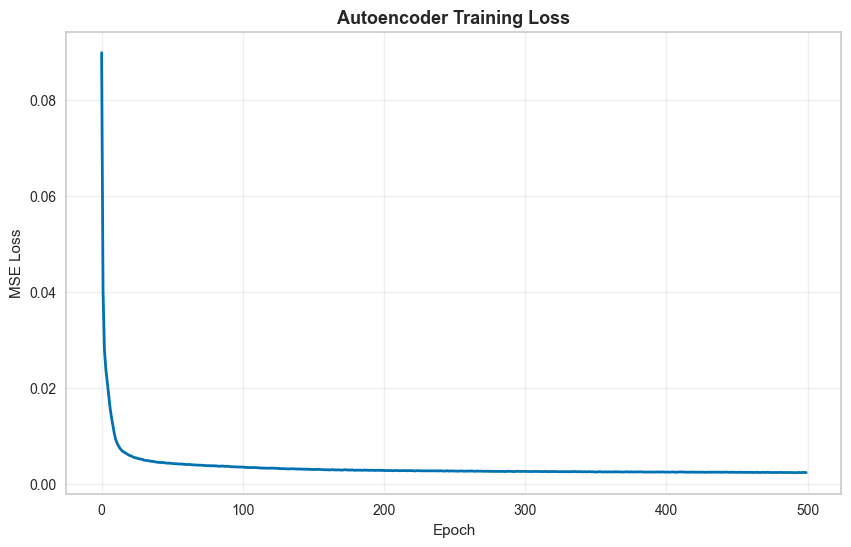

In [ ]:
#| label: autoencoder-training
#| echo: false

# Initialise and train 
input_dim = autoencoder_features.shape[1]
encoding_dim = input_dim # use same as input for denosing only, for dimensionality reduction and denosing we can set the value lower
model = TimeSeriesAutoencoder(input_dim, encoding_dim).to(device)

X_tensor = torch.FloatTensor(ae_scaled_data).to(device)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training loop
epochs = 500
train_losses = []
model.train()

print(f"Training autoencoder: {input_dim} -> {encoding_dim} dimensions")
for epoch in range(epochs):
    epoch_loss = 0.0
    batch_count = 0
    
    for batch_data, _ in dataloader:
        outputs = model(batch_data)
        loss = criterion(outputs, batch_data)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_count += 1
    
    avg_loss = epoch_loss / batch_count
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

# View training loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, color=custom_palette[1], linewidth=2)
plt.title('Autoencoder Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()



In [117]:
# Extract denoised/encoded features
model.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(ae_scaled_data).to(device)
    encoded_features = model.encode(X_tensor).cpu().numpy()

print(f"Encoded features shape: {encoded_features.shape}")



Encoded features shape: (3038, 36)


Analyzing optimal clusters for autoencoder features...


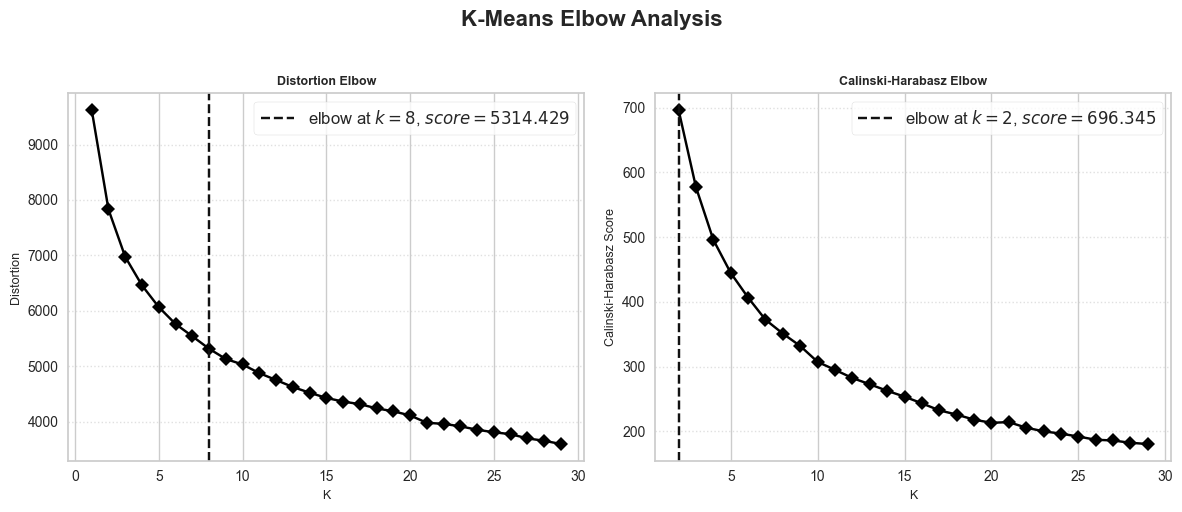

In [ ]:
#| label: fig-ae-elbow-analysis
#| fig-cap: "Elbow analysis for autoencoder-based features"
#| echo: false

# Does elbow appears different? 
print("Analyzing optimal clusters for autoencoder features...")
kmeans_elbow(
    X=encoded_features,
    palette=custom_palette,
    k_distortion=(1, 30),
    k_ch=(2, 30),
)

Do you see an albow? No? This could be up to 30 clusters, the last one could have been up to 20 too. Lets try 20 here.  

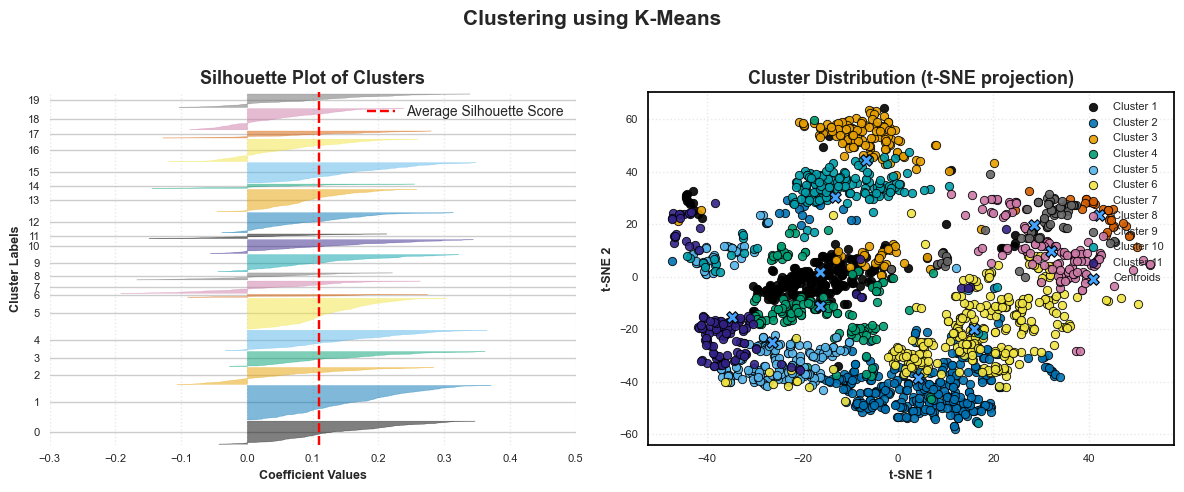

In [ ]:
#| label: fig-ae-cluster-visualization
#| fig-cap: "Autoencoder cluster visualization with silhouette analysis"
#| echo: false

# Cluster with 'optimal k' based on elbow analysis
optimal_k = 20  # feel free to adjust 

ae_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init='auto',
    max_iter=3000,
    algorithm='elkan',
    random_state=5363
)
ae_cluster_labels = ae_kmeans.fit_predict(encoded_features)

# lets take a look with silhouette and PCA (pinch of salt)
kmeans_cluster_visuals(
    X=encoded_features,
    kmeans=ae_kmeans,
    y_kmeans=ae_cluster_labels,
    cluster_colors=custom_palette,
    font_main='Arial',
    font_alt='Courier New',
    color_grid='lightgray',
    color_line='black',
    scatter_color_edge='black'
)




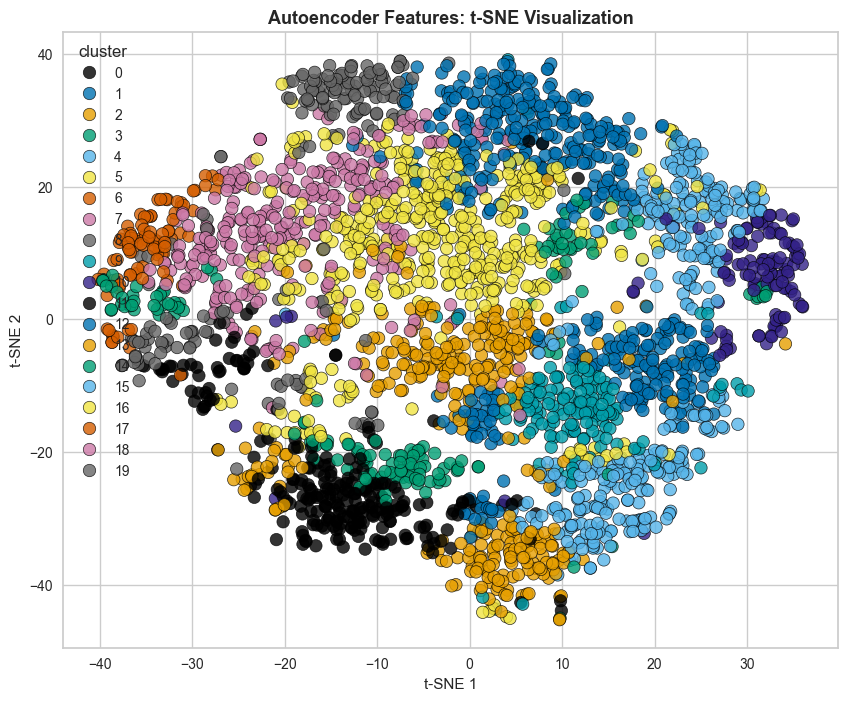

In [ ]:
#| label: fig-ae-tsne-clusters
#| fig-cap: "t-SNE visualization of autoencoder-based clusters"
#| echo: false

# Create t-SNE visualization using existing approach
ae_tsne = TSNE(
        n_components=2, 
        early_exaggeration=40,
        perplexity=60, 
        n_iter=1200, 
        random_state=86743, 
        method = 'barnes_hut',
        init="pca",
        n_jobs = -1
    )

ae_tsne_results = ae_tsne.fit_transform(encoded_features)

# Create DataFrame for plotting
ae_tsne_df = pd.DataFrame(ae_tsne_results, columns=['tsne1', 'tsne2'])
ae_tsne_df['cluster'] = ae_cluster_labels

# Plot using existing style
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=ae_tsne_df,
    x='tsne1',
    y='tsne2',
    hue='cluster',
    palette=custom_palette,
    s=80,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)
plt.title('Autoencoder Features: t-SNE Visualization', fontsize=13, fontweight='bold')
plt.xlabel('t-SNE 1', fontsize=11)
plt.ylabel('t-SNE 2', fontsize=11)
plt.show()


In [ ]:
#| label: tbl-cluster-comparison
#| tbl-cap: "Cross-tabulation comparing original clusters vs autoencoder clusters"
#| echo: false

# Create AE DataFrame
ae_feature_df = pd.DataFrame(encoded_features, columns=[f'ae_dim_{i}' for i in range(encoding_dim)])
ae_feature_df['unique_id'] = feature_df['unique_id'].values
ae_feature_df['ae_cluster'] = ae_cluster_labels
ae_feature_df = pd.concat([ae_feature_df, ae_tsne_df[['tsne1', 'tsne2']]], axis=1)

# Lets see how our AE clusters compare to the original clusters
comparison_df = pd.merge(
    feature_df[['unique_id', 'cluster']].rename(columns={'cluster': 'original_cluster'}),
    ae_feature_df[['unique_id', 'ae_cluster']],
    on='unique_id'
)

# cross-tab
cluster_comparison = pd.crosstab(
    comparison_df['original_cluster'],
    comparison_df['ae_cluster'],
    margins=True
)

print("\nClustering Comparison (Original vs Autoencoder):")
print(cluster_comparison)


Clustering Comparison (Original vs Autoencoder):
ae_cluster          0    1    2    3    4    5   6    7   8    9  ...  11  \
original_cluster                                                  ...       
0                 176   21    3  121    0    9   0    0   0    0  ...   0   
1                   0    5    0    8  172    8   0    0   0    5  ...   0   
2                   6    4   65    0    1    0   0    0   0  136  ...   1   
3                   3    0    0    0    1  143   0    2   0    5  ...   0   
4                   3    0    0    0    0    5   0   95   5    2  ...  17   
5                  25    0   88    0    0    4   0    1  18   10  ...  11   
6                   0  288    0    8   12  115   0    0   0    1  ...   0   
7                   0    0    0    0    0    0  27   15  42    0  ...  14   
All               213  318  156  137  186  284  27  113  65  159  ...  43   

ae_cluster         12   13  14   15   16  17   18   19   All  
original_cluster                       

In [126]:
ae_static_df = ae_feature_df[['unique_id', 'ae_cluster']].copy()

# One-hot encode the cluster variable
cluster_dummies = pd.get_dummies(ae_static_df['ae_cluster'], prefix='ae_cluster')
ae_static_df = pd.concat([ae_static_df[['unique_id']], cluster_dummies], axis=1)

print(ae_static_df.columns)

Index(['unique_id', 'ae_cluster_0', 'ae_cluster_1', 'ae_cluster_2',
       'ae_cluster_3', 'ae_cluster_4', 'ae_cluster_5', 'ae_cluster_6',
       'ae_cluster_7', 'ae_cluster_8', 'ae_cluster_9', 'ae_cluster_10',
       'ae_cluster_11', 'ae_cluster_12', 'ae_cluster_13', 'ae_cluster_14',
       'ae_cluster_15', 'ae_cluster_16', 'ae_cluster_17', 'ae_cluster_18',
       'ae_cluster_19'],
      dtype='object')


In [ ]:
#| label: ae-model-training
#| echo: false

early_stop_patience= 50
h = 90 

hyperparams = {'n_blocks': [1, 2, 1], 'mlp_units': [[512, 512], [512, 512], [512, 512]], 'n_pool_kernel_size': [2, 2, 2], 'n_freq_downsample': [48, 24, 1], 'learning_rate': 0.0011929467406727122, 'max_steps': 10000}

# Lets built a simple model and see how it performs
models = [
    NHITS(
        random_seed=52735,
        input_size=90,  
        h=h,
        max_steps=hyperparams['max_steps'],  
        scaler_type='standard',   
        loss=MAE(),                
        hist_exog_list= None,      
        futr_exog_list=['price'],  
        stat_exog_list=['ae_cluster_0', 'ae_cluster_1', 'ae_cluster_2',
       'ae_cluster_3', 'ae_cluster_4', 'ae_cluster_5', 'ae_cluster_6',
       'ae_cluster_7', 'ae_cluster_8', 'ae_cluster_9', 'ae_cluster_10',
       'ae_cluster_11', 'ae_cluster_12', 'ae_cluster_13', 'ae_cluster_14',
       'ae_cluster_15', 'ae_cluster_16', 'ae_cluster_17', 'ae_cluster_18',
       'ae_cluster_19'],    
        early_stop_patience_steps=early_stop_patience,
        learning_rate=hyperparams['learning_rate'],  
        n_blocks=hyperparams['n_blocks'], 
        mlp_units=hyperparams['mlp_units'],  
        n_pool_kernel_size=hyperparams['n_pool_kernel_size'], 
        n_freq_downsample=hyperparams['n_freq_downsample'], 
        alias='AutoNHITS_ae_clustered'
    )
]



Seed set to 52735


In [128]:
# Initialise global forecasting framework
nf = NeuralForecast(
    models=models,
    freq='D',  # Daily frequency
    #normalizer=None  # Let individual models handle scaling
)

nf.fit(
    df=train_df,
    static_df=ae_static_df,  # Static DataFrame with cluster information
    val_size=90,  # Validation window size
    verbose=True
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.7 M  | train
-------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.823    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=10000` reached.


In [129]:
# Generate predictions with optimized models
ae_predictions = nf.predict(futr_df=val_df,static_df=ae_static_df)

ae_predictions.head(n =3)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,ds,AutoNHITS_ae_clustered
unique_id,,
FOODS_1_001_CA_3,2016-03-22,1.496848
FOODS_1_001_CA_3,2016-03-23,1.496558
FOODS_1_001_CA_3,2016-03-24,1.496850


In [130]:
# add auto pred to eval_df
eval_df_updated = eval_df_updated.merge(
    ae_predictions, 
    on=['unique_id', 'ds'], 
    how='left'
)

# model list
updated_models = ['NHITS_with_clusters', 'NHITS_no_clusters', 'AutoNHITS_clustered', 'AutoNHITS_no_clusters', 'AutoNHITS_ae_clustered']

In [135]:
eval_df_updated

,unique_id,ds,NHITS_with_clusters,NHITS_no_clusters,SeasonalNaive,Naive,y,AutoNHITS_clustered,AutoNHITS_no_clusters,AutoNHITS_ae_clustered
0,FOODS_1_001_CA_3,2016-03-22,1.487739,1.523633,1.0,3.0,1.0,1.742673,1.529140,1.496848
1,FOODS_1_001_CA_3,2016-03-23,1.444373,1.523793,1.0,3.0,2.0,1.743071,1.528656,1.496558
2,FOODS_1_001_CA_3,2016-03-24,1.366226,1.518980,1.0,3.0,2.0,1.742796,1.529064,1.496850
3,FOODS_1_001_CA_3,2016-03-25,1.352583,1.492150,2.0,3.0,2.0,1.742905,1.520315,1.496920
4,FOODS_1_001_CA_3,2016-03-26,1.393387,1.451231,3.0,3.0,13.0,1.742974,1.503462,1.496889
...,...,...,...,...,...,...,...,...,...,...
273415,HOUSEHOLD_2_516_CA_3,2016-06-15,1.000087,0.997773,2.0,1.0,1.0,1.002385,0.995169,1.000645
273416,HOUSEHOLD_2_516_CA_3,2016-06-16,1.000150,0.997844,1.0,1.0,1.0,1.002330,0.995724,1.000599
273417,HOUSEHOLD_2_516_CA_3,2016-06-17,1.000163,0.997986,1.0,1.0,1.0,1.002382,0.995892,1.000553
273418,HOUSEHOLD_2_516_CA_3,2016-06-18,1.000155,0.998042,1.0,1.0,1.0,1.002382,0.995937,1.000630


In [ ]:
#| label: tbl-ae-model-metrics
#| tbl-cap: "Performance metrics including autoencoder-clustered model"
#| echo: false

# re-run eval
agg_metrics_updated = evaluate(
    eval_df_updated, 
    models=updated_models,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,
    id_col='unique_id', 
    time_col='ds',
    target_col='y',
    agg_fn='mean'
)

series_metrics_updated = evaluate(
    eval_df_updated, 
    models=updated_models,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,      
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

print("Updated Overall Metrics:")
print(agg_metrics_updated)

Updated Overall Metrics:
  metric  NHITS_with_clusters  NHITS_no_clusters  AutoNHITS_clustered  \
0    mae             1.422563           1.449423             1.436863   
1    mse            11.188759          11.756340            12.286255   
2   rmse             2.015219           2.048115             2.027901   
3   mase             1.061908           1.069357             1.061952   
4   mape             0.492804           0.486487             0.508287   
5  smape             0.203730           0.207393             0.202182   

   AutoNHITS_no_clusters  AutoNHITS_ae_clustered  
0               1.428758                1.401617  
1              10.964179               10.349054  
2               2.019830                1.999018  
3               1.058899                1.054320  
4               0.504157                0.483939  
5               0.203788                0.201639  


In [132]:
comprehensive_summary_updated, _ = create_summary(agg_metrics_updated, series_metrics_updated)
print("\nUpdated Model Performance Summary:")
print(comprehensive_summary_updated)

Total time series: 3038
Metrics evaluated: 4
Ranking based on aggregate RMSE
Maximum possible total wins: 12152

Updated Model Performance Summary:
                    Model  Rank  mae  mse  rmse  mase  total_wins  \
0  AutoNHITS_ae_clustered   1.0  560  561   561   560        2242   
4     NHITS_with_clusters   2.0  989  502   502   989        2982   
2   AutoNHITS_no_clusters   3.0  469  628   628   469        2194   
1     AutoNHITS_clustered   4.0  596  602   602   596        2396   
3       NHITS_no_clusters   5.0  424  745   745   424        2338   

   Win_Percentage  mae_win_pct  mse_win_pct  rmse_win_pct  mase_win_pct  
0           18.45        18.43        18.47         18.47         18.43  
4           24.54        32.55        16.52         16.52         32.55  
2           18.05        15.44        20.67         20.67         15.44  
1           19.72        19.62        19.82         19.82         19.62  
3           19.24        13.96        24.52         24.52         1

In [ ]:


rel_rmse_auto_cl_val = rel_rmse(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_clustered'].values,
                eval_df_updated['SeasonalNaive'].values
            )

rel_mae_auto_cl_val = rel_mae(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_clustered'].values,
                eval_df_updated['SeasonalNaive'].values
            )

rel_rmse_auto_no_cl_val = rel_rmse(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_no_clusters'].values,
                eval_df_updated['SeasonalNaive'].values
            )

rel_mae_auto_no_cl_val = rel_mae(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_no_clusters'].values,
                eval_df_updated['SeasonalNaive'].values
            )

rel_rmse_ae_cl_val = rel_rmse(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_ae_clustered'].values,
                eval_df_updated['SeasonalNaive'].values
            )

rel_mae_ae_cl_val = rel_mae(
                eval_df_updated['y'].values,
                eval_df_updated['AutoNHITS_ae_clustered'].values,
                eval_df_updated['SeasonalNaive'].values
            )



In [134]:
print(f"Relative RMSE with Clusters: {rel_rmse_cl_val:.4f}")
print(f"Relative MAE with Clusters: {rel_mae_cl_val:.4f}")
print(f"Relative RMSE no Clusters: {rel_rmse_no_cl_val:.4f}")
print(f"Relative MAE no Clusters: {rel_mae_no_cl_val:.4f}")


print(f"Relative RMSE with AutoNHITS clustered: {rel_rmse_auto_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS clustered: {rel_mae_auto_cl_val:.4f}")      
print(f"Relative RMSE with AutoNHITS no clusters: {rel_rmse_auto_no_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS no clusters: {rel_mae_auto_no_cl_val:.4f}")
print(f"Relative RMSE with AutoNHITS AE clustered: {rel_rmse_ae_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS AE clustered: {rel_mae_ae_cl_val:.4f}")


Relative RMSE with Clusters: 0.8651
Relative MAE with Clusters: 0.8013
Relative RMSE no Clusters: 0.8868
Relative MAE no Clusters: 0.8165
Relative RMSE with AutoNHITS clustered: 0.9066
Relative MAE with AutoNHITS clustered: 0.8094
Relative RMSE with AutoNHITS no clusters: 0.8564
Relative MAE with AutoNHITS no clusters: 0.8048
Relative RMSE with AutoNHITS AE clustered: 0.8320
Relative MAE with AutoNHITS AE clustered: 0.7895


Given the results of modelling and evaluation, we can see firstly that clustering helps a little much with default HPs, but the tuned the model with clusters isn't actually better. Although the unclustered HP tuned model is better than it's direcy default comparison. This may point to an issue with the Validation tpe which is a simple trainign split, a lack comparisons, an issue with missing important HPs like batch size from the tuning, or failure to increas the top end of HPs like `max_step`. Regardless, increasing the number of clusters and denoising the data gave us some significant improvements at the full model level which is how we should evaluate this. However, the individual series performance is not fantastic, which does point towards the neccesity of using more than one model in a system, and selecting between or combining all, or some, of them. Its also the case that we should probably have run a new HP test with the ae clusters, as the clusters are different to the original set. 

Additionally...

* we could use multiple models i.e. a GFM catboost model and ensemble the results together
* apply the models to clusters, or clusters plus some hierachal level (to some extent this is what the M5 winners did with their models without the clustering) 
* allow training to run for longer

There are of course other consideration too. For example, we could have run the autoencoder with a stopping parameters i.e. lr = 0.0001, or change the parameters of the autoencoder to see if we can get better quality clusters.   

Creating ts features from exogenous variables (i.e. price) can help, if the exogenous is predictive of the dependent variable. Another option would be to build more, or specifc, features that depend on knoweldge and EDA. We also ignored alot of features i.e. holidays, promotions etc. A final but not exhaustive solution would be to clean the data properly, as there outliers, missing values and other issues that could be causing problems.  



In [ ]:
#| label: cluster-specific-training
#| echo: false

# list to store predictions for each cluster

all_cluster_predictions = []

# Loop through each cluster
for cluster_num in range(20):  # 0 to 19
    cluster_col = f'ae_cluster_{cluster_num}'
    
    print(f"Training model for cluster {cluster_num}...")
    
    # Get unique_ids belonging to this cluster
    cluster_ids = ae_static_df[ae_static_df[cluster_col] == True]['unique_id'].tolist()
    
    # Skip if no items in this cluster
    if len(cluster_ids) == 0:
        print(f"Cluster {cluster_num} is empty, skipping...")
        continue
    
    print(f"Cluster {cluster_num} has {len(cluster_ids)} unique_ids")
    
    # Subset training and validation data for this cluster
    cluster_train_df = train_df[train_df['unique_id'].isin(cluster_ids)].copy()
    cluster_val_df = val_df[val_df['unique_id'].isin(cluster_ids)].copy()
    
    # Create model for this cluster (no static features needed since all items are in same cluster)
    cluster_model = [
        NHITS(
            random_seed=52735,
            input_size=90,  
            h=h,
            max_steps=3500,  
            scaler_type='standard',   
            loss=MAE(),                
            hist_exog_list=None,      
            futr_exog_list=['price'],  
            stat_exog_list=None,  # No cluster features needed - all items are same cluster
            early_stop_patience_steps=early_stop_patience,
            learning_rate=0.001,  
            alias=f'NHITS_cluster_{cluster_num}'
        )
    ]
    
    # Initialize and fit model for this cluster
    cluster_nf = NeuralForecast(
        models=cluster_model,
        freq='D'
    )
    
    cluster_nf.fit(
        df=cluster_train_df,
        val_size=90,
        verbose=False  # Set to True if you want detailed logs
    )
    
    # Generate predictions for this cluster
    cluster_predictions = cluster_nf.predict(futr_df=cluster_val_df)
    
    # Rename the prediction column to a consistent name
    cluster_predictions = cluster_predictions.rename(columns={
        f'NHITS_cluster_{cluster_num}': 'NHITS_cluster_specific_default'
    })
    
    # Add cluster number for tracking
    cluster_predictions['cluster_num'] = cluster_num
    
    # Collect predictions
    all_cluster_predictions.append(cluster_predictions)




Seed set to 52735


Training model for cluster 0...
Cluster 0 has 213 unique_ids


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.9 M  | train
-------------------------------------------------------
2.9 M     Trainable params
0         Non-trainable params
2.9 M     Total params
11.444    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=3500` reached.
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [163]:
cluster_specific_predictions = pd.concat(all_cluster_predictions, ignore_index=False)
cluster_specific_predictions.drop(columns=['cluster_num'], inplace=True)

In [164]:
print(cluster_specific_predictions.head(n=3))
print(cluster_specific_predictions.shape)

                         ds  NHITS_cluster_specific_default
unique_id                                                  
FOODS_1_005_CA_3 2016-03-22                        2.806146
FOODS_1_005_CA_3 2016-03-23                        2.865472
FOODS_1_005_CA_3 2016-03-24                        2.963897
(273420, 2)


In [159]:
# Merge with evaluation DataFrame
eval_df_with_individ_clust_mods = eval_df_updated.merge(
    cluster_specific_predictions, 
    on=['unique_id', 'ds'], 
    how='left'
)

In [ ]:
#eval_df_with_individ_clust_mods.to_csv('eval_df_with_individual_cluster_models.csv', index=False)

In [ ]:
#| label: tbl-final-metrics
#| tbl-cap: "Comprehensive performance comparison of all models"
#| echo: false

# Update model list
updated_models_with_clusters = [
    'NHITS_with_clusters', 
    'NHITS_no_clusters', 
    'AutoNHITS_clustered', 
    'AutoNHITS_no_clusters', 
    'AutoNHITS_ae_clustered',
    'NHITS_cluster_specific',  # New cluster-specific model
    'NHITS_cluster_specific_default'  # Default cluster-specific model 
]

# Re-run evaluation
agg_metrics_with_clusters = evaluate(
    eval_df_with_individ_clust_mods, 
    models=updated_models_with_clusters,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,
    id_col='unique_id', 
    time_col='ds',
    target_col='y',
    agg_fn='mean'
)

series_metrics_with_clusters = evaluate(
    eval_df_with_individ_clust_mods, 
    models=updated_models_with_clusters,
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=train_df,      
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

print(agg_metrics_with_clusters)

  metric  NHITS_with_clusters  NHITS_no_clusters  AutoNHITS_clustered  \
0    mae             1.422563           1.449423             1.436863   
1    mse            11.188759          11.756340            12.286255   
2   rmse             2.015219           2.048115             2.027901   
3   mase             1.061908           1.069357             1.061952   
4   mape             0.492804           0.486487             0.508287   
5  smape             0.203730           0.207393             0.202182   

   AutoNHITS_no_clusters  AutoNHITS_ae_clustered  NHITS_cluster_specific  \
0               1.428758                1.401617                1.477164   
1              10.964179               10.349054               12.032556   
2               2.019830                1.999018                2.069746   
3               1.058899                1.054320                1.129117   
4               0.504157                0.483939                0.531670   
5               0.203788        

In [ ]:
#| label: tbl-relative-metrics-final
#| tbl-cap: "Relative performance metrics against seasonal naive baseline"
#| echo: false

rel_mae_ae_cl_sp_def_val = rel_mae(
                eval_df_with_individ_clust_mods['y'].values,
                eval_df_with_individ_clust_mods['NHITS_cluster_specific_default'].values,
                eval_df_with_individ_clust_mods['SeasonalNaive'].values
            )

rel_mae_ae_cl_sp_hp_val = rel_mae(
                eval_df_with_individ_clust_mods['y'].values,
                eval_df_with_individ_clust_mods['NHITS_cluster_specific'].values,
                eval_df_with_individ_clust_mods['SeasonalNaive'].values
            )

rel_rmse_ae_cl_sp_def_val = rel_rmse(
                eval_df_with_individ_clust_mods['y'].values,
                eval_df_with_individ_clust_mods['NHITS_cluster_specific_default'].values,
                eval_df_with_individ_clust_mods['SeasonalNaive'].values
            )

rel_rmse_ae_cl_sp_hp_val = rel_rmse(
                eval_df_with_individ_clust_mods['y'].values,
                eval_df_with_individ_clust_mods['NHITS_cluster_specific'].values,
                eval_df_with_individ_clust_mods['SeasonalNaive'].values
            )






print(f"Relative RMSE with Clusters: {rel_rmse_cl_val:.4f}")
print(f"Relative MAE with Clusters: {rel_mae_cl_val:.4f}")
print(f"Relative RMSE no Clusters: {rel_rmse_no_cl_val:.4f}")
print(f"Relative MAE no Clusters: {rel_mae_no_cl_val:.4f}")


print(f"Relative RMSE with AutoNHITS clustered: {rel_rmse_auto_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS clustered: {rel_mae_auto_cl_val:.4f}")      
print(f"Relative RMSE with AutoNHITS no clusters: {rel_rmse_auto_no_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS no clusters: {rel_mae_auto_no_cl_val:.4f}")
print(f"Relative RMSE with AutoNHITS AE clustered: {rel_rmse_ae_cl_val:.4f}")
print(f"Relative MAE with AutoNHITS AE clustered: {rel_mae_ae_cl_val:.4f}")

print(f"Relative RMSE with NHITS cluster specific default: {rel_rmse_ae_cl_sp_def_val:.4f}")
print(f"Relative MAE with NHITS cluster specific default: {rel_mae_ae_cl_sp_def_val:.4f}")
print(f"Relative RMSE with NHITS cluster specific hyperopt: {rel_rmse_ae_cl_sp_hp_val:.4f}")
print(f"Relative MAE with NHITS cluster specific hyperopt: {rel_mae_ae_cl_sp_hp_val:.4f}")

Relative RMSE with Clusters: 0.8651
Relative MAE with Clusters: 0.8013
Relative RMSE no Clusters: 0.8868
Relative MAE no Clusters: 0.8165
Relative RMSE with AutoNHITS clustered: 0.9066
Relative MAE with AutoNHITS clustered: 0.8094
Relative RMSE with AutoNHITS no clusters: 0.8564
Relative MAE with AutoNHITS no clusters: 0.8048
Relative RMSE with AutoNHITS AE clustered: 0.8320
Relative MAE with AutoNHITS AE clustered: 0.7895
Relative RMSE with NHITS cluster specific default: 1.0170
Relative MAE with NHITS cluster specific default: 0.8224
Relative RMSE with NHITS cluster specific hyperopt: 0.8972
Relative MAE with NHITS cluster specific hyperopt: 0.8321


In [176]:
comprehensive_summary_updated, series_summary_updated = create_summary(agg_metrics_with_clusters, series_metrics_with_clusters)
print("\nUpdated Model Performance Summary:")
print(comprehensive_summary_updated)

Total time series: 3038
Metrics evaluated: 4
Ranking based on aggregate RMSE
Maximum possible total wins: 12152

Updated Model Performance Summary:
                            Model  Rank  mae  mse  rmse  mase  total_wins  \
0          AutoNHITS_ae_clustered   1.0  315  336   336   315        1302   
6             NHITS_with_clusters   2.0  460  305   305   460        1530   
2           AutoNHITS_no_clusters   3.0  318  469   469   318        1574   
1             AutoNHITS_clustered   4.0  381  400   400   381        1562   
5               NHITS_no_clusters   5.0  288  553   553   288        1682   
4  NHITS_cluster_specific_default   6.0  771  540   540   771        2622   
3          NHITS_cluster_specific   7.0  505  435   435   505        1880   

   Win_Percentage  mae_win_pct  mse_win_pct  rmse_win_pct  mase_win_pct  
0           10.71        10.37        11.06         11.06         10.37  
6           12.59        15.14        10.04         10.04         15.14  
2           1

We have some interesting results here, globally our best rmse is which is labelled AutoNHITS_ae_clustered, a GFM model that makes use of clusters built on autoencoded data. It also has a relative RMSE of 0.832 and relative mae of 0.7895, this is more than a trival improvement the naive model and the NHITS with no clusters. Despite this the individual series performance is not disapointing, with it ranking dead last with 332 when comparing all the GFM models, interestingly the cluster specific GFMs (20 models we build) both the default and tuned (auto) versions along withe the NHITS with no clusters are the best performers here. 

This tells us that the global error metric is likley being affected by the individual series performance. It may also be the case that the forecasts created by the global model are fairly simple.  

In [177]:
series_metrics_with_clusters

,unique_id,metric,NHITS_with_clusters,NHITS_no_clusters,AutoNHITS_clustered,AutoNHITS_no_clusters,AutoNHITS_ae_clustered,NHITS_cluster_specific,NHITS_cluster_specific_default
0,FOODS_1_001_CA_3,mae,1.180247,1.188823,1.206439,1.185757,1.185930,1.170879,1.189725
1,FOODS_1_002_CA_3,mae,0.657465,0.668716,0.669541,0.670772,0.637544,0.633367,0.633414
2,FOODS_1_003_CA_3,mae,0.870254,0.867209,0.889262,0.869573,0.893301,0.883883,0.881772
3,FOODS_1_004_CA_3,mae,5.088471,5.079937,2.713390,4.836512,3.065573,2.909043,5.077657
4,FOODS_1_005_CA_3,mae,2.116465,2.161619,2.113950,2.183418,2.101564,2.081155,2.099361
...,...,...,...,...,...,...,...,...,...
18223,HOUSEHOLD_2_512_CA_3,smape,0.270312,0.263630,0.281098,0.250170,0.295073,0.296689,0.296499
18224,HOUSEHOLD_2_513_CA_3,smape,0.233438,0.237408,0.227780,0.231504,0.242465,0.251624,0.257606
18225,HOUSEHOLD_2_514_CA_3,smape,0.065976,0.066515,0.066391,0.067232,0.066068,0.066014,0.065981
18226,HOUSEHOLD_2_515_CA_3,smape,0.059082,0.059512,0.063485,0.058927,0.043908,0.045721,0.053324


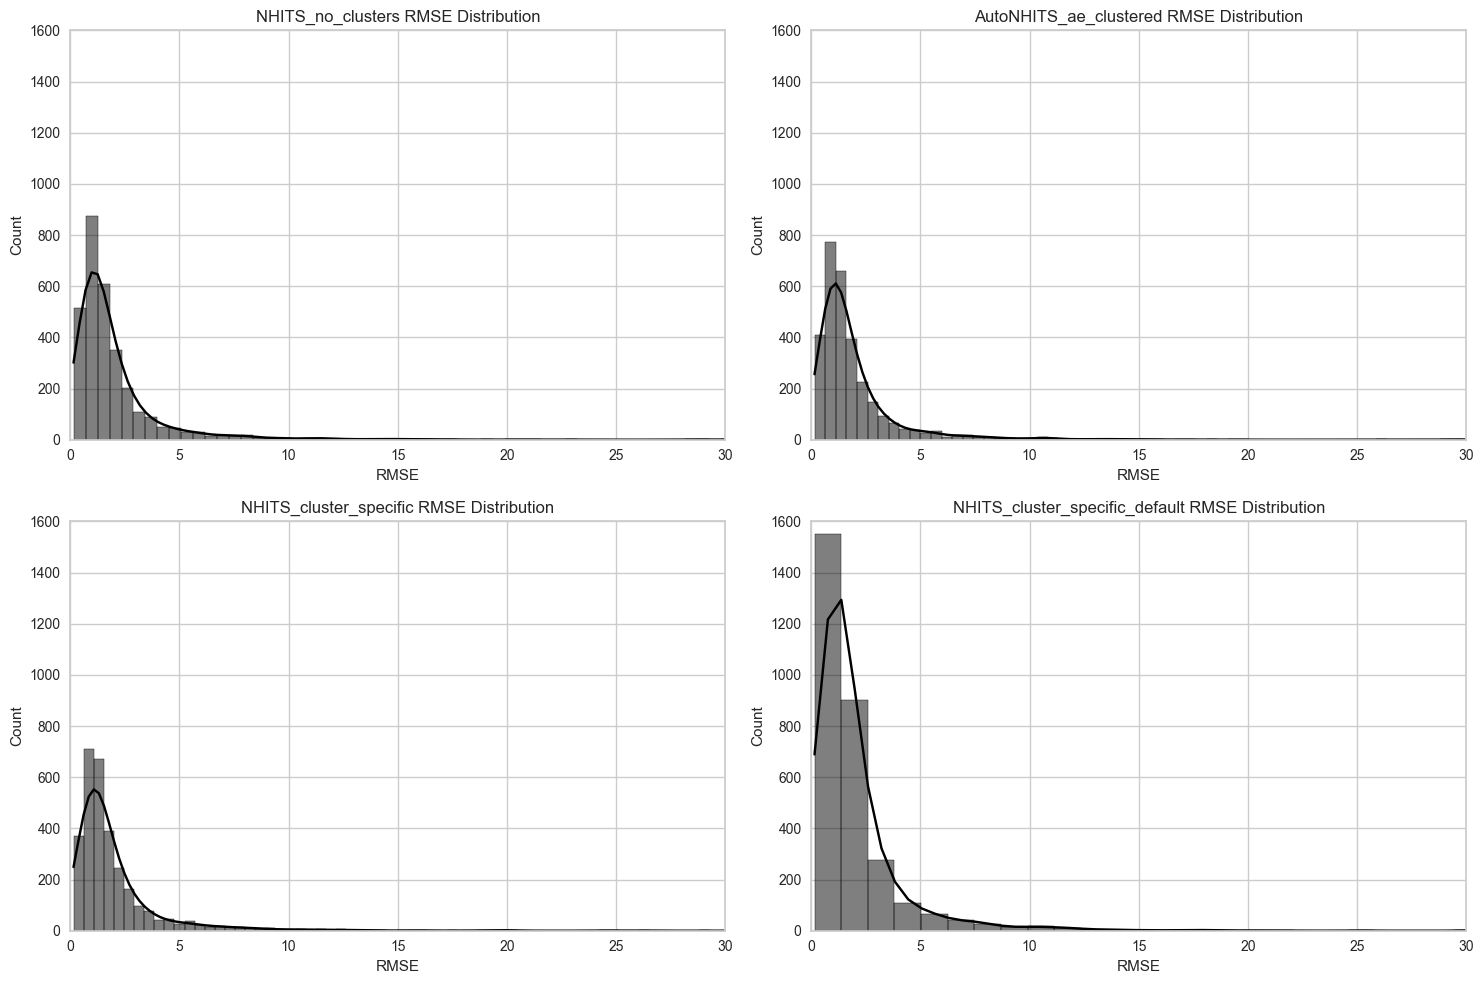

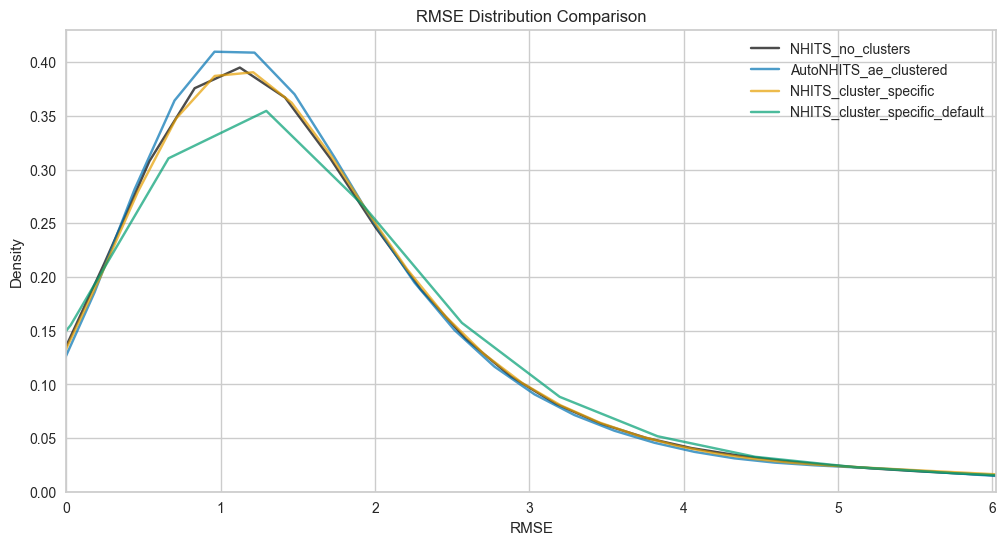

In [ ]:
#| label: fig-rmse-distributions
#| fig-cap: "RMSE distribution comparison across selected models"
#| echo: false

rmse_data = series_metrics_with_clusters[series_metrics_with_clusters['metric'] == 'rmse']

# Select the 4 models to compare
mod_compares = ['NHITS_no_clusters', 'AutoNHITS_ae_clustered', 'NHITS_cluster_specific', 'NHITS_cluster_specific_default']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Create histogram for each model
for i, model in enumerate(mod_compares):
    sns.histplot(data=rmse_data, x=model, bins=100, kde=True, ax=axes[i])
    axes[i].set_title(f'{model} RMSE Distribution')
    axes[i].set_xlabel('RMSE')
    axes[i].set_ylabel('Count')
    axes[i].set_xlim(0, 30)
    axes[i].set_ylim(0, 1600)  # Adjust y-axis limit for better visibility

plt.tight_layout()
plt.show()

# Alternative: Combined density plot
plt.figure(figsize=(12, 6))
for model in mod_compares:
    sns.kdeplot(data=rmse_data, x=model, label=model, alpha=0.7)

plt.xlabel('RMSE')
plt.ylabel('Density')
plt.title('RMSE Distribution Comparison')
plt.legend()
plt.xlim(0, rmse_data[mod_compares].quantile(0.95).max())  # Limit x-axis to 95th perc to avoid outliers
plt.show()

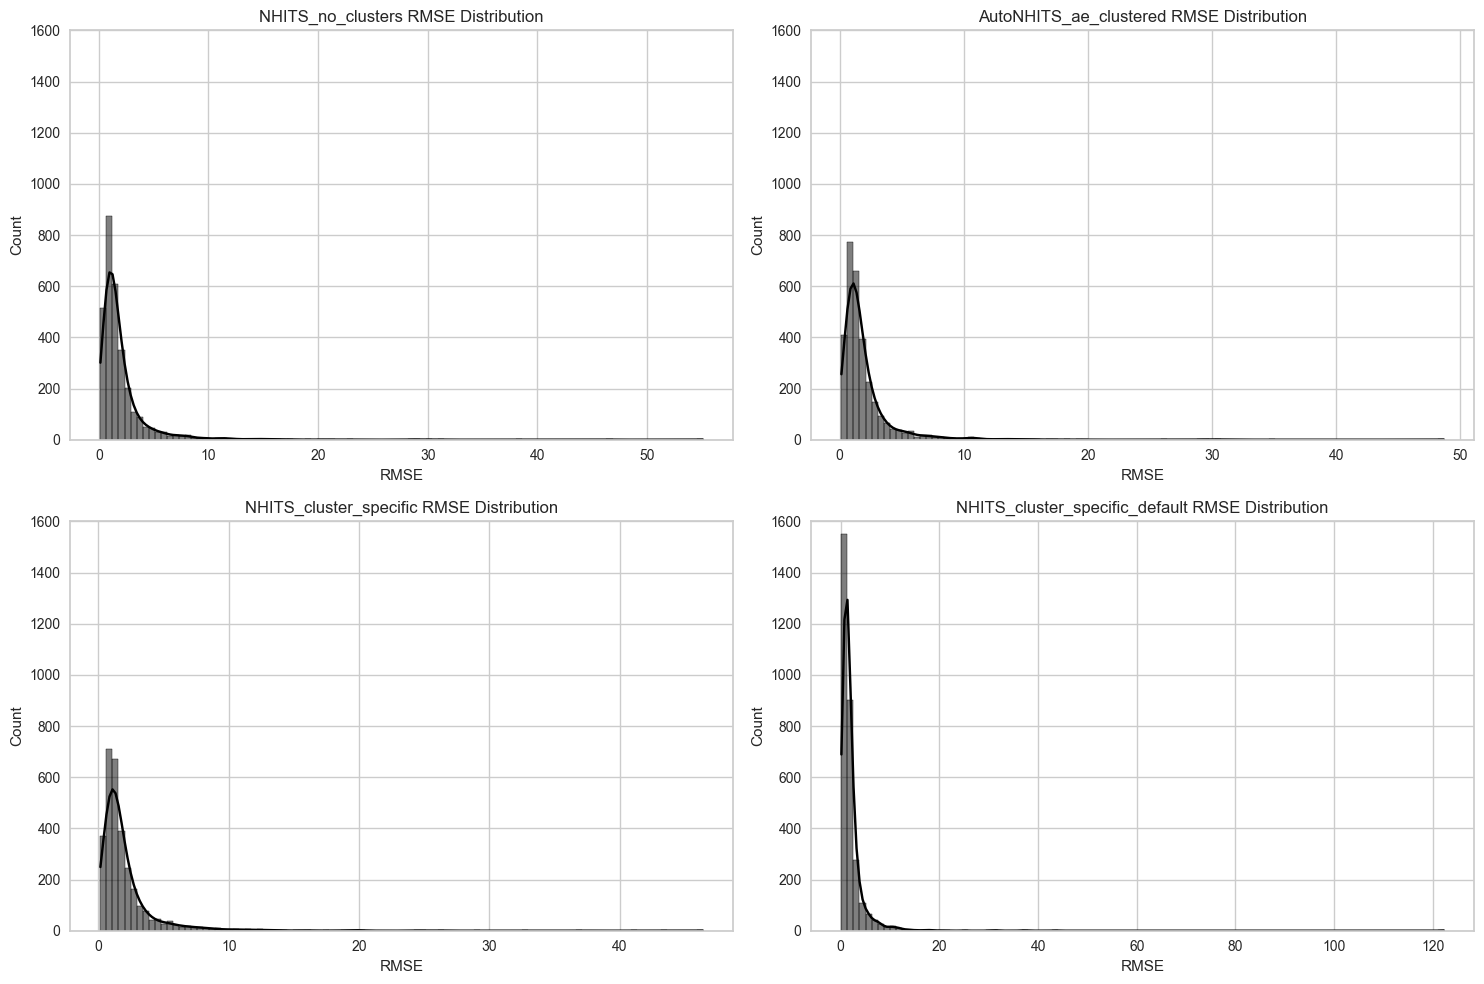

In [ ]:
#| label: fig-rmse-distributions-full
#| fig-cap: "Full range RMSE distributions showing outliers"
#| echo: false

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Create histogram for each model
for i, model in enumerate(mod_compares):
    sns.histplot(data=rmse_data, x=model, bins=100, kde=True, ax=axes[i])
    axes[i].set_title(f'{model} RMSE Distribution')
    axes[i].set_xlabel('RMSE')
    axes[i].set_ylabel('Count')
    # axes[i].set_xlim(0, 30) removed to see full range longer suggests outlying forecasts
    axes[i].set_ylim(0, 1600)  # Adjust y-axis limit for better visibility

plt.tight_layout()
plt.show()

Although not a direct assessment these graphs add weight to our hypothesis that outlying forecasts may be affecting the cluster specifc GFMs for the default HPs (wider bins, longer x-axis), which is not surprising given it is untuned for each cluster. The same can be said of the the cluster specific NHITS models which uses the HPs we obtained for the tuned global model with clusters. Neither have appropriate HPs for the individual clusters, which is likely why they are not performing as well as the NHITS with no clusters.

If we wanted to do this well we should tune the HPs for each cluster, this is not a small task. But in production we don't have to tune models regularly without cause. We could of course, use the tuned model GFM with all AE clusters and the cluster-specific GFM together, either ensembelling or selecting between them. We can't do that here because we didn't use a validation set.  

In [ ]:
# price features 

# create feature DataFrame with price features

# append _price to each column name in price_df

# add this to feature_df join on unique_id

# denoise price features using the same autoencoder

# build clusters 

# create t-sne visualization

# build new static_df with sales_by_price clusters

# build new with sales_by_price clusters

# use auto model 

# compare performance 

# summary 